# Topline Report Analysis (Notebook 03)

Report-ready tables, summary statistics, and compact figures for the written
top-lines memo to AISI. This notebook is the *reporting* counterpart to
notebooks 01 (core analysis) and 02 (geographic maps); those notebooks are not
modified.

Every output is keyed to one of three populations and labelled accordingly:

1. **Occupation-level** — 861 O\*NET occupations, independent of the ad sample.
2. **Adzuna corpus** — ad-weighted statistics on the 5M random sample, an
   unbiased estimate of statistics on the full ~30M Adzuna corpus.
3. **UK employment** — only via occupation-level employment weighting (ASHE
   Table 14 / BRES). Conditional on the weighting source being available.

All scalars cited in the report are written to a single
`store/analysis/report_pack/topline_numbers.json` so the report author has one
auditable source.

In [ ]:
import json
import warnings
from datetime import datetime, timezone
from pathlib import Path

import duckdb
import matplotlib
# Pick a matplotlib backend that suits how the notebook is being run.
# Script execution (`python file.py`) gets Agg so no GUI window pops up.
# Jupyter / nbl fill keeps the inline backend so figure outputs are
# embedded in the .ipynb.
try:
    from IPython import get_ipython
    _ipy = get_ipython()
    if _ipy is None:
        matplotlib.use('Agg')
    else:
        _ipy.run_line_magic('matplotlib', 'inline')
except (ImportError, AttributeError):
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'store').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# Inputs
ONET_SCORES_PATH = ROOT / "store/outputs/onet_exposure_scores/scores.csv"
BT_SCORES_PATH = ROOT / "store/outputs/onet_exposure_scores/score_task_exposure_bt/gpt-4.1-mini/scores.csv"
ONET_DATA_PATH = ROOT / "store/inputs/onet/db_30_0_text/Occupation Data.txt"
GEO_LAD_PATH = ROOT / "store/outputs/production_5m/production_5m/geo_lad.csv"
AD_EXPOSURE_PATH = ROOT / "store/pipeline/production_5m/compute_job_ad_exposure/ad_exposure.parquet"
ADZUNA_DB_PATH = ROOT / "store/inputs/adzuna.duckdb"

# Outputs
FIG_DIR = ROOT / "store/analysis/figures"
TABLES_DIR = ROOT / "store/analysis/tables"
REPORT_DIR = ROOT / "store/analysis/report_pack"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Plot conventions inherited from notebooks 01/02
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})
PRIMARY = '#2C3E50'
SECONDARY = '#2980B9'
ACCENT = '#E74C3C'
GREEN = '#27AE60'
ORANGE = '#F39C12'
PURPLE = '#9B59B6'
GREY_MED = '#95A5A6'
GREY_LIGHT = '#ECF0F1'

SCORE_VARIANTS = {
    'absolute': {'col': 'task_exposure_mean', 'label': 'Absolute Task Exposure', 'label_short': 'Absolute'},
    'bt':       {'col': 'task_exposure_bt_mean', 'label': 'Bradley-Terry Task Exposure', 'label_short': 'Bradley-Terry'},
}

ONET_MAJOR_NAMES = {
    11: "Management", 13: "Business & Financial", 15: "Computer & Mathematical",
    17: "Architecture & Engineering", 19: "Life, Physical & Social Science",
    21: "Community & Social Service", 23: "Legal", 25: "Educational Instruction",
    27: "Arts, Design, Entertainment", 29: "Healthcare Practitioners",
    31: "Healthcare Support", 33: "Protective Service", 35: "Food Preparation & Serving",
    37: "Building & Grounds Cleaning", 39: "Personal Care & Service", 41: "Sales",
    43: "Office & Administrative", 45: "Farming, Fishing, Forestry",
    47: "Construction & Extraction", 49: "Installation, Maintenance, Repair",
    51: "Production", 53: "Transportation & Material Moving",
}

# topline_numbers.json is accumulated incrementally; see Section 9 for the export.
topline_numbers: dict = {
    "metadata": {
        "run_name": "production_5m",
        "executed_at": datetime.now(timezone.utc).isoformat(timespec='seconds'),
        "inputs": {
            "onet_scores": str(ONET_SCORES_PATH.relative_to(ROOT)),
            "bt_scores": str(BT_SCORES_PATH.relative_to(ROOT)),
            "geo_lad": str(GEO_LAD_PATH.relative_to(ROOT)),
            "ad_exposure": str(AD_EXPOSURE_PATH.relative_to(ROOT)),
            "adzuna_db": str(ADZUNA_DB_PATH.relative_to(ROOT)),
        },
    },
}

print("Paths and conventions configured.")
print(f"  ROOT = {ROOT}")
print(f"  ad_exposure.parquet exists: {AD_EXPOSURE_PATH.exists()}")
print(f"  geo_lad.csv exists:        {GEO_LAD_PATH.exists()}")

Paths and conventions configured.
  ROOT = /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2
  ad_exposure.parquet exists: True
  geo_lad.csv exists:        True


## Section 0 — Sampling audit and sample composition

Population: **the 5M analysed sample** (a uniform random draw from the Adzuna
corpus). Audit numbers are descriptive of the sample as analysed.

We open a DuckDB session that attaches `adzuna.duckdb` read-only and registers
`ad_exposure.parquet` as a view, so the same connection serves every
downstream section without materialising the 5M rows in pandas.

In [ ]:
con = duckdb.connect(":memory:")
con.execute(f"ATTACH '{ADZUNA_DB_PATH}' AS adz (READ_ONLY)")
con.execute(f"CREATE VIEW ad_exp AS SELECT * FROM read_parquet('{AD_EXPOSURE_PATH}')")

### Canonical schema of `adzuna.ads`

Saved to `tables/adzuna_schema.csv` for the data dictionary appendix.

In [ ]:
schema_rows = con.execute("DESCRIBE adz.ads").fetchall()
schema_df = pd.DataFrame(schema_rows, columns=['column_name', 'column_type', 'null', 'key', 'default', 'extra'])
schema_df = schema_df[['column_name', 'column_type', 'null']]
schema_df.to_csv(TABLES_DIR / "adzuna_schema.csv", index=False)
print(f"adz.ads has {len(schema_df)} columns")
print(schema_df.to_string(index=False))

adz.ads has 33 columns
           column_name column_type null
                    id      BIGINT   NO
                  year     INTEGER   NO
                 month     INTEGER   NO
          date_created     VARCHAR  YES
                 title     VARCHAR  YES
           description     VARCHAR  YES
          location_raw     VARCHAR  YES
               geo_lat     VARCHAR  YES
               geo_lng     VARCHAR  YES
               LAD22CD     VARCHAR  YES
               LAD22NM     VARCHAR  YES
               LAD24CD     VARCHAR  YES
           category_id      BIGINT  YES
         category_name     VARCHAR  YES
           company_raw     VARCHAR  YES
            company_id      DOUBLE  YES
    normalised_company     VARCHAR  YES
            salary_min      DOUBLE  YES
            salary_max      DOUBLE  YES
       salary_currency     VARCHAR  YES
      salary_predicted      DOUBLE  YES
            salary_raw     VARCHAR  YES
         contract_type     VARCHAR  YES
         contract

### Date field on `adzuna.ads`

The ads table carries the posted date in two forms: an integer `year` column
(1-byte, indexed at ingest) and a VARCHAR `date_created` (full ISO string).
Year-level analysis uses `year` directly; finer-grained temporal slices would
parse `date_created`.

In [ ]:
year_breakdown = con.execute("""
  SELECT year, COUNT(*) AS n_ads
  FROM adz.ads
  GROUP BY year ORDER BY year
""").fetchdf()
print("Year breakdown (full corpus):")
print(year_breakdown.to_string(index=False))

Year breakdown (full corpus):
 year    n_ads
 2022 19689586
 2025 10274491


### Coverage counts on the 5M analysed sample

These counts speak to the 5M analysed sample only. The
`ad_exposure.parquet` file written by `compute_job_ad_exposure` contains
only ads that received at least one valid O\*NET match — failed-match ads
are dropped upstream and never appear here. The match denominator is
therefore the requested `sample_n` (5,000,000), not the parquet row count;
the difference is the count of ads dropped during reranking or LLM
filtering. LAD coverage is computed against the parquet (ads that survived
matching), since LAD-aggregated scores can only come from ads that have
scores.

In [ ]:
# sample_n requested by the production run, used as the denominator for
# match_rate. Sourced from config/run_defs.toml [runs.production_5m].
SAMPLE_N_REQUESTED = 5_000_000

audit_total = con.execute("""
  SELECT
    COUNT(*) AS n_ads_total,
    COUNT(*) FILTER (WHERE n_matches > 0) AS n_ads_with_match,
    COUNT(*) FILTER (WHERE error IS NOT NULL) AS n_ads_with_error
  FROM ad_exp
""").fetchone()
n_ads_total, n_ads_with_match, n_ads_with_error = audit_total

audit_lad = con.execute("""
  SELECT
    COUNT(*) FILTER (WHERE a.LAD22CD IS NOT NULL) AS n_ads_with_lad,
    COUNT(*) FILTER (WHERE a.LAD22CD IS NOT NULL AND e.n_matches > 0) AS n_ads_with_lad_and_match
  FROM ad_exp e
  LEFT JOIN adz.ads a ON e.ad_id = a.id
""").fetchone()
n_ads_with_lad, n_ads_with_lad_and_match = audit_lad

n_ads_dropped = SAMPLE_N_REQUESTED - n_ads_total

audit_year = con.execute("""
  SELECT a.year,
         COUNT(*) AS n_ads,
         COUNT(*) FILTER (WHERE a.LAD22CD IS NOT NULL) AS n_ads_with_lad,
         COUNT(*) FILTER (WHERE a.LAD22CD IS NOT NULL AND e.n_matches > 0) AS n_ads_with_lad_and_match
  FROM ad_exp e
  LEFT JOIN adz.ads a ON e.ad_id = a.id
  GROUP BY a.year ORDER BY a.year
""").fetchdf()
print(f"Requested sample_n:   {SAMPLE_N_REQUESTED:,}")
print(f"Delivered (parquet):  {n_ads_total:,}")
print(f"Dropped during match: {n_ads_dropped:,}")
print()
print("By year:")
print(audit_year.to_string(index=False))

# Assemble the audit table that is exported to disk.
audit_rows = [
    {'metric': 'n_ads_requested', 'value': SAMPLE_N_REQUESTED},
    {'metric': 'n_ads_total', 'value': n_ads_total},
    {'metric': 'n_ads_with_match', 'value': n_ads_with_match},
    {'metric': 'n_ads_dropped_upstream', 'value': n_ads_dropped},
    {'metric': 'n_ads_with_error_flag', 'value': n_ads_with_error},
    {'metric': 'n_ads_with_lad', 'value': n_ads_with_lad},
    {'metric': 'n_ads_with_lad_and_match', 'value': n_ads_with_lad_and_match},
]
for _, r in audit_year.iterrows():
    yr = int(r['year']) if pd.notna(r['year']) else -1
    audit_rows.append({'metric': f'n_ads_{yr}', 'value': int(r['n_ads'])})
    audit_rows.append({'metric': f'n_ads_{yr}_with_lad', 'value': int(r['n_ads_with_lad'])})
    audit_rows.append({'metric': f'n_ads_{yr}_with_lad_and_match', 'value': int(r['n_ads_with_lad_and_match'])})
audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(TABLES_DIR / "sampling_audit.csv", index=False)
print(f"\nSaved {TABLES_DIR / 'sampling_audit.csv'}")

Requested sample_n:   5,000,000
Delivered (parquet):  4,997,227
Dropped during match: 2,773

By year:
 year   n_ads  n_ads_with_lad  n_ads_with_lad_and_match
 2022 3285356         2130001                   2130001
 2025 1711871         1173986                   1173986

Saved /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/tables/sampling_audit.csv


### Sampling audit figure

Per-year breakdown of the analysed sample: total ads in the parquet vs ads
with a LAD22CD. The gap is the share lacking geographic data (Adzuna's own
coverage gap, not a pipeline issue).

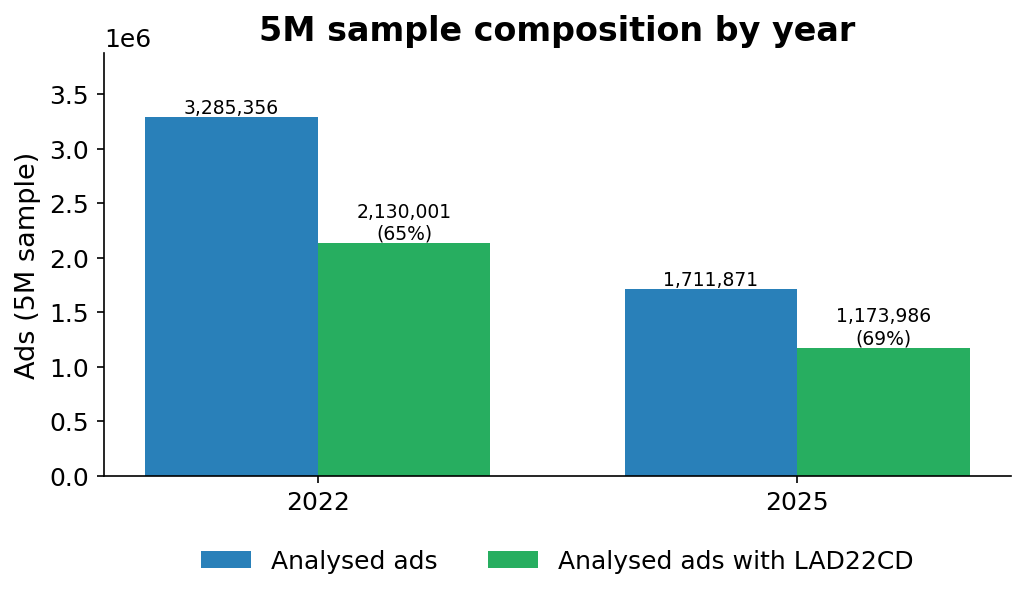

Saved /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/figures/sampling_audit.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.2))
years = audit_year['year'].astype(int).tolist()
heights_all = audit_year['n_ads'].tolist()
heights_lad = audit_year['n_ads_with_lad'].tolist()
x = np.arange(len(years))
w = 0.36
ax.bar(x - w/2, heights_all, w, color=SECONDARY, label='Analysed ads')
ax.bar(x + w/2, heights_lad, w, color=GREEN, label='Analysed ads with LAD22CD')
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years])
ax.set_ylabel('Ads (5M sample)')
ax.set_title('5M sample composition by year', fontweight='bold')
for xi, h_all, h_lad in zip(x, heights_all, heights_lad):
    ax.text(xi - w/2, h_all, f'{h_all:,}', ha='center', va='bottom', fontsize=9)
    pct = h_lad / h_all
    ax.text(xi + w/2, h_lad, f'{h_lad:,}\n({pct:.0%})', ha='center', va='bottom', fontsize=9)
ax.legend(frameon=False, loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.12))
ax.margins(y=0.18)
plt.tight_layout()
plt.savefig(FIG_DIR / "sampling_audit.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR / 'sampling_audit.png'}")

### Scalars for the report

Stored under the canonical keys named in the spec so the report author can grep
`topline_numbers.json` directly.

In [ ]:
# Match rate uses the requested sample denominator (5M) — the share of the
# random sample that ended up with a usable score row.
match_rate = n_ads_with_match / SAMPLE_N_REQUESTED
# LAD-coverage rate is computed over the analysed ads (those in the parquet),
# since LAD-aggregated scores can only come from those rows.
lad_coverage_rate = n_ads_with_lad / n_ads_total

# Per-year totals (defensive lookup so we don't assume both years are present).
by_year_total = {int(r['year']): int(r['n_ads']) for _, r in audit_year.iterrows()}
n_ads_2022 = by_year_total.get(2022, 0)
n_ads_2025 = by_year_total.get(2025, 0)

topline_numbers['sampling'] = {
    'n_ads_requested': SAMPLE_N_REQUESTED,
    'n_ads_total': int(n_ads_total),
    'n_ads_with_match': int(n_ads_with_match),
    'n_ads_dropped_upstream': int(n_ads_dropped),
    'n_ads_with_lad': int(n_ads_with_lad),
    'n_ads_with_lad_and_match': int(n_ads_with_lad_and_match),
    'n_ads_2022': n_ads_2022,
    'n_ads_2025': n_ads_2025,
    'match_rate': float(match_rate),
    'lad_coverage_rate': float(lad_coverage_rate),
}
print(f"match_rate (with score / requested) = {match_rate:.4f}")
print(f"lad_coverage_rate (with LAD / analysed) = {lad_coverage_rate:.4f}")
print(f"n_ads_2022 / 2025 = {n_ads_2022:,} / {n_ads_2025:,}")

match_rate (with score / requested) = 0.9994
lad_coverage_rate (with LAD / analysed) = 0.6612
n_ads_2022 / 2025 = 3,285,356 / 1,711,871


## Section 1 — Load and frame

Build the canonical occupation- and LAD-level frames that every downstream
section reuses. The ad-level DuckDB views were set up in Section 0.

In [ ]:
# Occupation-level scores. The combined scores.csv currently ships the
# absolute task-exposure variants; BT columns live alongside in a model-keyed
# subdirectory and must be merged in. The merge is defensive: if a future
# `combine_onet_exposure` includes the BT columns in scores.csv directly, we
# only bring in BT columns that aren't already present so we never end up
# with pandas-style `_x` / `_y` duplicates.
onet_df = pd.read_csv(ONET_SCORES_PATH)
bt_df = pd.read_csv(BT_SCORES_PATH)
_bt_new_cols = [c for c in bt_df.columns if c != 'onet_code' and c not in onet_df.columns]
if _bt_new_cols:
    onet_df = onet_df.merge(bt_df[['onet_code', *_bt_new_cols]], on='onet_code', how='left')
    print(f"merged BT columns from {BT_SCORES_PATH.name}: {_bt_new_cols}")
else:
    print("scores.csv already contains all BT columns; skipping merge")

# Occupation titles from the O*NET source table (tab-separated).
onet_titles = pd.read_csv(ONET_DATA_PATH, sep='\t')[['O*NET-SOC Code', 'Title']]
onet_titles = onet_titles.rename(columns={'O*NET-SOC Code': 'onet_code', 'Title': 'title'})
onet_df = onet_df.merge(onet_titles, on='onet_code', how='left')

# Major group code and name from the leading two digits of the SOC code.
onet_df['major_code'] = onet_df['onet_code'].str[:2].astype(int)
onet_df['major_group'] = onet_df['major_code'].map(ONET_MAJOR_NAMES)

assert onet_df['title'].notna().all(), "some occupations missing titles"
assert onet_df['major_group'].notna().all(), "unmapped major group code"
assert onet_df.shape[0] == 861, f"expected 861 occupations, got {onet_df.shape[0]}"
print(f"onet_df: {onet_df.shape[0]} occupations × {onet_df.shape[1]} columns")
print(f"  score columns: {[c for c in onet_df.columns if 'score' in c or 'exposure' in c or 'presence' in c]}")
print(f"  major groups:  {onet_df['major_group'].nunique()}")

merged BT columns from scores.csv: ['task_exposure_bt_mean', 'task_exposure_bt_importance_weighted']
onet_df: 861 occupations × 13 columns
  score columns: ['felten_score', 'presence_physical', 'presence_emotional', 'presence_creative', 'presence_composite', 'task_exposure_mean', 'task_exposure_importance_weighted', 'task_exposure_bt_mean', 'task_exposure_bt_importance_weighted']
  major groups:  22


In [ ]:
# LAD-level aggregation (ad-weighted means within each LAD, written by
# aggregate_geo).
geo_df = pd.read_csv(GEO_LAD_PATH)
print(f"geo_df: {geo_df.shape[0]} LADs × {geo_df.shape[1]} columns")
print(f"  total ads covered: {geo_df['n_ads'].sum():,}")
print(f"  ads with valid scores: {geo_df['n_ads_with_scores'].sum():,}")

geo_df: 373 LADs × 13 columns
  total ads covered: 3,304,617
  ads with valid scores: 3,304,617


## Section 2 — Data dictionary

Explicit, machine-readable schema for every column of the three deliverable
tables (occupation, ad, LAD). Sourced from `CODEBASE_STRUCTURE.md` (node
reference) and the live data — `dtype` is read from each table at import time
so the file always matches what is actually on disk.

This is the single highest-leverage artifact in the report pack: every column
in any output table the report author touches has a one-line description, a
denominator, and a pointer back to the producing pipeline node.

In [ ]:
DATA_DICT = [
    # ----- Occupation table: scores.csv ---------------------------------
    {'table': 'occupation', 'column': 'onet_code',
     'description': '8-digit O*NET-SOC code (e.g. 13-2011.00). Joinable to occupation lookups.',
     'units': 'code', 'denominator': '861 occupations', 'source_node': 'combine_onet_exposure'},
    {'table': 'occupation', 'column': 'felten_score',
     'description': 'Felten AIOE ability-application AI exposure: importance-weighted average of per-ability exposures, where each ability is weighted by its relatedness to ten AI application domains under the configured progress scenario.',
     'units': '[0, 1]', 'denominator': '861 occupations', 'source_node': 'score_felten'},
    {'table': 'occupation', 'column': 'presence_physical',
     'description': 'Physical presence requirement: in-person, manual, outdoor and machinery use, derived from O*NET Work Context, Work Activities, Skills.',
     'units': '[0, 1]', 'denominator': '861 occupations', 'source_node': 'score_presence'},
    {'table': 'occupation', 'column': 'presence_emotional',
     'description': 'Emotional presence requirement: caring, negotiating, coaching, conflict-handling, social perceptiveness.',
     'units': '[0, 1]', 'denominator': '861 occupations', 'source_node': 'score_presence'},
    {'table': 'occupation', 'column': 'presence_creative',
     'description': 'Creative presence requirement: decision-making latitude, creative thinking, writing.',
     'units': '[0, 1]', 'denominator': '861 occupations', 'source_node': 'score_presence'},
    {'table': 'occupation', 'column': 'presence_composite',
     'description': 'Mean of physical, emotional and creative presence.',
     'units': '[0, 1]', 'denominator': '861 occupations', 'source_node': 'score_presence'},
    {'table': 'occupation', 'column': 'task_exposure_mean',
     'description': 'Mean LLM-classified task exposure across the occupation\'s O*NET tasks. Each task receives a 0/1/2 score (NO CHANGE / COLLABORATION / LLM-INDEPENDENT) and is mapped to [0, 1] via division by 2.',
     'units': '[0, 1]', 'denominator': '861 occupations', 'source_node': 'score_task_exposure'},
    {'table': 'occupation', 'column': 'task_exposure_importance_weighted',
     'description': 'Same as task_exposure_mean but weighted by O*NET task importance (IM scale).',
     'units': '[0, 1]', 'denominator': '861 occupations', 'source_node': 'score_task_exposure'},
    {'table': 'occupation', 'column': 'task_exposure_bt_mean',
     'description': 'Bradley-Terry pairwise task exposure (mean of task-level BT scores per occupation). Three-round adaptive LLM pairwise comparisons fit a BT model over tasks.',
     'units': '[0, 1]', 'denominator': '861 occupations', 'source_node': 'score_task_exposure_bt'},
    {'table': 'occupation', 'column': 'task_exposure_bt_importance_weighted',
     'description': 'Same as task_exposure_bt_mean but weighted by O*NET task importance.',
     'units': '[0, 1]', 'denominator': '861 occupations', 'source_node': 'score_task_exposure_bt'},

    # ----- Ad table: ad_exposure.parquet ---------------------------------
    {'table': 'ad', 'column': 'ad_id',
     'description': 'Unique ad identifier. Joinable to adzuna.ads.id for posted-date, salary, employer, location and category metadata.',
     'units': 'integer', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},
    {'table': 'ad', 'column': 'n_matches',
     'description': 'Number of O*NET occupations matched to this ad after LLM-filter and reranker keep-list (post negative-rerank filter applied in compute_job_ad_exposure).',
     'units': 'integer', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},
    {'table': 'ad', 'column': 'felten_score',
     'description': 'Per-ad weighted average of occupation-level felten_score across the ad\'s matched occupations. Weights are softmax(min-max(rerank_score)/0.7).',
     'units': '[0, 1]', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},
    {'table': 'ad', 'column': 'presence_physical',
     'description': 'Per-ad weighted average of occupation-level presence_physical. Weighting as above.',
     'units': '[0, 1]', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},
    {'table': 'ad', 'column': 'presence_emotional',
     'description': 'Per-ad weighted average of occupation-level presence_emotional.',
     'units': '[0, 1]', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},
    {'table': 'ad', 'column': 'presence_creative',
     'description': 'Per-ad weighted average of occupation-level presence_creative.',
     'units': '[0, 1]', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},
    {'table': 'ad', 'column': 'presence_composite',
     'description': 'Per-ad weighted average of occupation-level presence_composite.',
     'units': '[0, 1]', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},
    {'table': 'ad', 'column': 'task_exposure_mean',
     'description': 'Per-ad weighted average of occupation-level task_exposure_mean.',
     'units': '[0, 1]', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},
    {'table': 'ad', 'column': 'task_exposure_importance_weighted',
     'description': 'Per-ad weighted average of occupation-level task_exposure_importance_weighted.',
     'units': '[0, 1]', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},
    {'table': 'ad', 'column': 'task_exposure_bt_mean',
     'description': 'Per-ad weighted average of occupation-level task_exposure_bt_mean.',
     'units': '[0, 1]', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},
    {'table': 'ad', 'column': 'task_exposure_bt_importance_weighted',
     'description': 'Per-ad weighted average of occupation-level task_exposure_bt_importance_weighted.',
     'units': '[0, 1]', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},
    {'table': 'ad', 'column': 'error',
     'description': 'Failure flag from compute_job_ad_exposure. Empty in the production_5m run (failed-match ads are dropped upstream and never appear in the parquet).',
     'units': 'integer or NULL', 'denominator': 'per ad', 'source_node': 'compute_job_ad_exposure'},

    # ----- LAD table: geo_lad.csv ----------------------------------------
    {'table': 'lad', 'column': 'LAD22CD',
     'description': 'ONS 2022 Local Authority District code (E06/E07/E08/E09/W06/S12/N09). Geographic primary key.',
     'units': 'code', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'LAD22NM',
     'description': 'ONS 2022 LAD name (district name).',
     'units': 'text', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'n_ads',
     'description': 'Total analysed ads with LAD22CD in this LAD (from the 5M sample).',
     'units': 'integer', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'n_ads_with_scores',
     'description': 'Subset of n_ads with n_matches > 0; the count contributing to LAD-level score means.',
     'units': 'integer', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'felten_score',
     'description': 'Ad-weighted mean of per-ad felten_score within this LAD (AVG ... FILTER WHERE n_matches > 0).',
     'units': '[0, 1]', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'presence_physical',
     'description': 'Ad-weighted mean of per-ad presence_physical within this LAD.',
     'units': '[0, 1]', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'presence_emotional',
     'description': 'Ad-weighted mean of per-ad presence_emotional within this LAD.',
     'units': '[0, 1]', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'presence_creative',
     'description': 'Ad-weighted mean of per-ad presence_creative within this LAD.',
     'units': '[0, 1]', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'presence_composite',
     'description': 'Ad-weighted mean of per-ad presence_composite within this LAD.',
     'units': '[0, 1]', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'task_exposure_mean',
     'description': 'Ad-weighted mean of per-ad task_exposure_mean within this LAD.',
     'units': '[0, 1]', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'task_exposure_importance_weighted',
     'description': 'Ad-weighted mean of per-ad task_exposure_importance_weighted within this LAD.',
     'units': '[0, 1]', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'task_exposure_bt_mean',
     'description': 'Ad-weighted mean of per-ad task_exposure_bt_mean within this LAD.',
     'units': '[0, 1]', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
    {'table': 'lad', 'column': 'task_exposure_bt_importance_weighted',
     'description': 'Ad-weighted mean of per-ad task_exposure_bt_importance_weighted within this LAD.',
     'units': '[0, 1]', 'denominator': 'per LAD', 'source_node': 'aggregate_geo'},
]

# Attach actual dtypes from the live tables so the dictionary matches disk.
_onet_dtypes = onet_df.dtypes.to_dict()
_geo_dtypes = geo_df.dtypes.to_dict()
_ad_dtypes = {r[0]: r[1] for r in con.execute("DESCRIBE ad_exp").fetchall()}
_dtype_lookup = {
    'occupation': {k: str(v) for k, v in _onet_dtypes.items()},
    'ad': _ad_dtypes,
    'lad': {k: str(v) for k, v in _geo_dtypes.items()},
}
for entry in DATA_DICT:
    entry['dtype'] = _dtype_lookup[entry['table']].get(entry['column'], 'unknown')

dict_df = pd.DataFrame(DATA_DICT, columns=['table', 'column', 'dtype', 'units', 'denominator', 'description', 'source_node'])
dict_df.to_csv(REPORT_DIR / "data_dictionary.csv", index=False)

# Also emit a Markdown rendering, grouped by table, for the report appendix.
md_lines = ["# Data dictionary\n"]
md_lines.append("Schema for the three deliverable tables produced by the AISI exposure index pipeline. "
                "Generated from `CODEBASE_STRUCTURE.md` plus live dtypes at import time.\n")
for tbl, label, path in [
    ('occupation', 'Occupation table', 'store/outputs/onet_exposure_scores/scores.csv'),
    ('ad', 'Ad table', 'store/pipeline/{run_name}/compute_job_ad_exposure/ad_exposure.parquet'),
    ('lad', 'LAD table', 'store/outputs/{run_name}/geo_lad.csv'),
]:
    sub = dict_df[dict_df['table'] == tbl]
    md_lines.append(f"\n## {label}\n")
    md_lines.append(f"Path: `{path}`. Rows: " + {
        'occupation': '861 (one per O*NET occupation).',
        'ad': '~5M (one per analysed advertisement; failed-match ads excluded).',
        'lad': '373 (UK Local Authority Districts with at least one ad).',
    }[tbl] + "\n")
    md_lines.append("| Column | Dtype | Units | Denominator | Source node | Description |")
    md_lines.append("|---|---|---|---|---|---|")
    for _, r in sub.iterrows():
        md_lines.append(f"| `{r['column']}` | {r['dtype']} | {r['units']} | {r['denominator']} | `{r['source_node']}` | {r['description']} |")
(REPORT_DIR / "data_dictionary.md").write_text("\n".join(md_lines) + "\n")

print(f"Wrote {len(dict_df)} data-dictionary entries across {dict_df['table'].nunique()} tables")
print(f"  {REPORT_DIR / 'data_dictionary.csv'}")
print(f"  {REPORT_DIR / 'data_dictionary.md'}")

Wrote 35 data-dictionary entries across 3 tables
  /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/report_pack/data_dictionary.csv
  /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/report_pack/data_dictionary.md


## Section 3 — Headline exposure distributions

Distributions of the four headline scores at three altitudes:

- **3a Occupation-level** — over the 861 O\*NET occupations. Sample-independent.
- **3b Ad-weighted (Adzuna corpus)** — DuckDB statistics on the 5M sample,
  ad-weighted, an unbiased estimate of the Adzuna corpus.
- **3c UK employment-weighted** — *deferred*. Requires ASHE Table 14 or BRES.

### 3a. Occupation-level distribution

In [ ]:
score_cols_all = [c for c in onet_df.columns
                  if c.startswith('felten_') or c.startswith('presence_')
                  or c.startswith('task_exposure_')]

def _summarise(series: pd.Series) -> dict:
    s = series.dropna()
    return {
        'mean': float(s.mean()),
        'std': float(s.std()),
        'min': float(s.min()),
        'p10': float(s.quantile(0.10)),
        'p25': float(s.quantile(0.25)),
        'median': float(s.median()),
        'p75': float(s.quantile(0.75)),
        'p90': float(s.quantile(0.90)),
        'max': float(s.max()),
    }

occ_dist = pd.DataFrame([
    {'score': c, **_summarise(onet_df[c])} for c in score_cols_all
])
occ_dist.to_csv(TABLES_DIR / "occupation_distribution.csv", index=False)
print("Occupation-level distribution (one row per score column):")
print(occ_dist.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# Headline scalars
topline_numbers['occupation_distribution'] = {
    'mean_task_exposure_occ':    float(onet_df['task_exposure_mean'].mean()),
    'mean_task_exposure_bt_occ': float(onet_df['task_exposure_bt_mean'].mean()),
    'median_task_exposure_occ':  float(onet_df['task_exposure_mean'].median()),
    'p90_task_exposure_occ':     float(onet_df['task_exposure_mean'].quantile(0.90)),
    'mean_felten_occ':           float(onet_df['felten_score'].mean()),
    'mean_presence_composite_occ': float(onet_df['presence_composite'].mean()),
}

Occupation-level distribution (one row per score column):
                               score   mean    std    min    p10    p25  median    p75    p90    max
                        felten_score 0.5834 0.0296 0.5179 0.5467 0.5569  0.5803 0.6125 0.6251 0.6335
                   presence_physical 0.4675 0.0876 0.2421 0.3429 0.4047  0.4747 0.5325 0.5804 0.6894
                  presence_emotional 0.5073 0.0835 0.2370 0.4014 0.4454  0.5074 0.5660 0.6152 0.7480
                   presence_creative 0.5885 0.1118 0.2863 0.4384 0.5075  0.5936 0.6785 0.7303 0.8994
                  presence_composite 0.5211 0.0623 0.3301 0.4388 0.4812  0.5248 0.5667 0.5963 0.6824
                  task_exposure_mean 0.3203 0.1727 0.0000 0.0652 0.1538  0.3750 0.4800 0.5000 0.8750
   task_exposure_importance_weighted 0.3204 0.1728 0.0000 0.0668 0.1520  0.3754 0.4821 0.5000 0.8709
               task_exposure_bt_mean 0.2729 0.1601 0.0054 0.0586 0.1226  0.2813 0.4098 0.4795 0.6515
task_exposure_bt_importance_weigh

### 3b. Ad-weighted distribution (Adzuna corpus)

Computed directly in DuckDB so the 5M rows never materialise in pandas.
Population: every analysed ad with `n_matches > 0` (which is every row of
`ad_exp` for the production_5m run). The four headline columns mirror
notebook 01's `score_distributions.png`.

In [ ]:
headline_cols = ['task_exposure_mean', 'task_exposure_bt_mean', 'felten_score', 'presence_composite']

ad_rows = []
for col in headline_cols:
    q = f"""
      SELECT
        AVG({col})    AS mean,
        STDDEV({col}) AS std,
        MIN({col})    AS min,
        QUANTILE_CONT({col}, 0.10) AS p10,
        QUANTILE_CONT({col}, 0.25) AS p25,
        MEDIAN({col}) AS median,
        QUANTILE_CONT({col}, 0.75) AS p75,
        QUANTILE_CONT({col}, 0.90) AS p90,
        MAX({col})    AS max,
        COUNT(*) FILTER (WHERE {col} > 0.5) / CAST(COUNT(*) AS DOUBLE) AS share_gt_0_5,
        COUNT(*) FILTER (WHERE {col} > 0.7) / CAST(COUNT(*) AS DOUBLE) AS share_gt_0_7
      FROM ad_exp WHERE n_matches > 0
    """
    row = con.execute(q).fetchone()
    ad_rows.append({
        'score': col, 'mean': row[0], 'std': row[1], 'min': row[2],
        'p10': row[3], 'p25': row[4], 'median': row[5], 'p75': row[6],
        'p90': row[7], 'max': row[8], 'share_gt_0_5': row[9], 'share_gt_0_7': row[10],
    })
ad_dist = pd.DataFrame(ad_rows)
ad_dist.to_csv(TABLES_DIR / "ad_weighted_distribution.csv", index=False)
print("Ad-weighted distribution (Adzuna corpus via 5M sample):")
print(ad_dist.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# Headline scalars
topline_numbers['ad_weighted_distribution'] = {
    'mean_task_exposure_ad':    float(ad_dist.loc[ad_dist.score == 'task_exposure_mean', 'mean'].iloc[0]),
    'mean_task_exposure_bt_ad': float(ad_dist.loc[ad_dist.score == 'task_exposure_bt_mean', 'mean'].iloc[0]),
    'median_task_exposure_ad':  float(ad_dist.loc[ad_dist.score == 'task_exposure_mean', 'median'].iloc[0]),
    'p90_task_exposure_ad':     float(ad_dist.loc[ad_dist.score == 'task_exposure_mean', 'p90'].iloc[0]),
    'share_ads_task_exposure_gt_0_5': float(ad_dist.loc[ad_dist.score == 'task_exposure_mean', 'share_gt_0_5'].iloc[0]),
    'share_ads_task_exposure_gt_0_7': float(ad_dist.loc[ad_dist.score == 'task_exposure_mean', 'share_gt_0_7'].iloc[0]),
}

Ad-weighted distribution (Adzuna corpus via 5M sample):
                score   mean    std    min    p10    p25  median    p75    p90    max  share_gt_0_5  share_gt_0_7
   task_exposure_mean 0.3816 0.1307 0.0000 0.1618 0.2889  0.4452 0.4902 0.4981 0.5448        0.0372        0.0000
task_exposure_bt_mean 0.3399 0.1460 0.0149 0.1234 0.2177  0.3599 0.4721 0.5161 0.6413        0.1488        0.0000
         felten_score 0.5916 0.0263 0.5278 0.5525 0.5681  0.5988 0.6154 0.6219 0.6329        1.0000        0.0000
   presence_composite 0.5219 0.0450 0.3301 0.4562 0.4925  0.5277 0.5540 0.5755 0.6764        0.7054        0.0000


#### Ad-weighted histogram panel

Histograms binned in DuckDB (50 equal-width bins) so the per-bin counts are
computed columnar over the 5M rows without loading them into pandas.

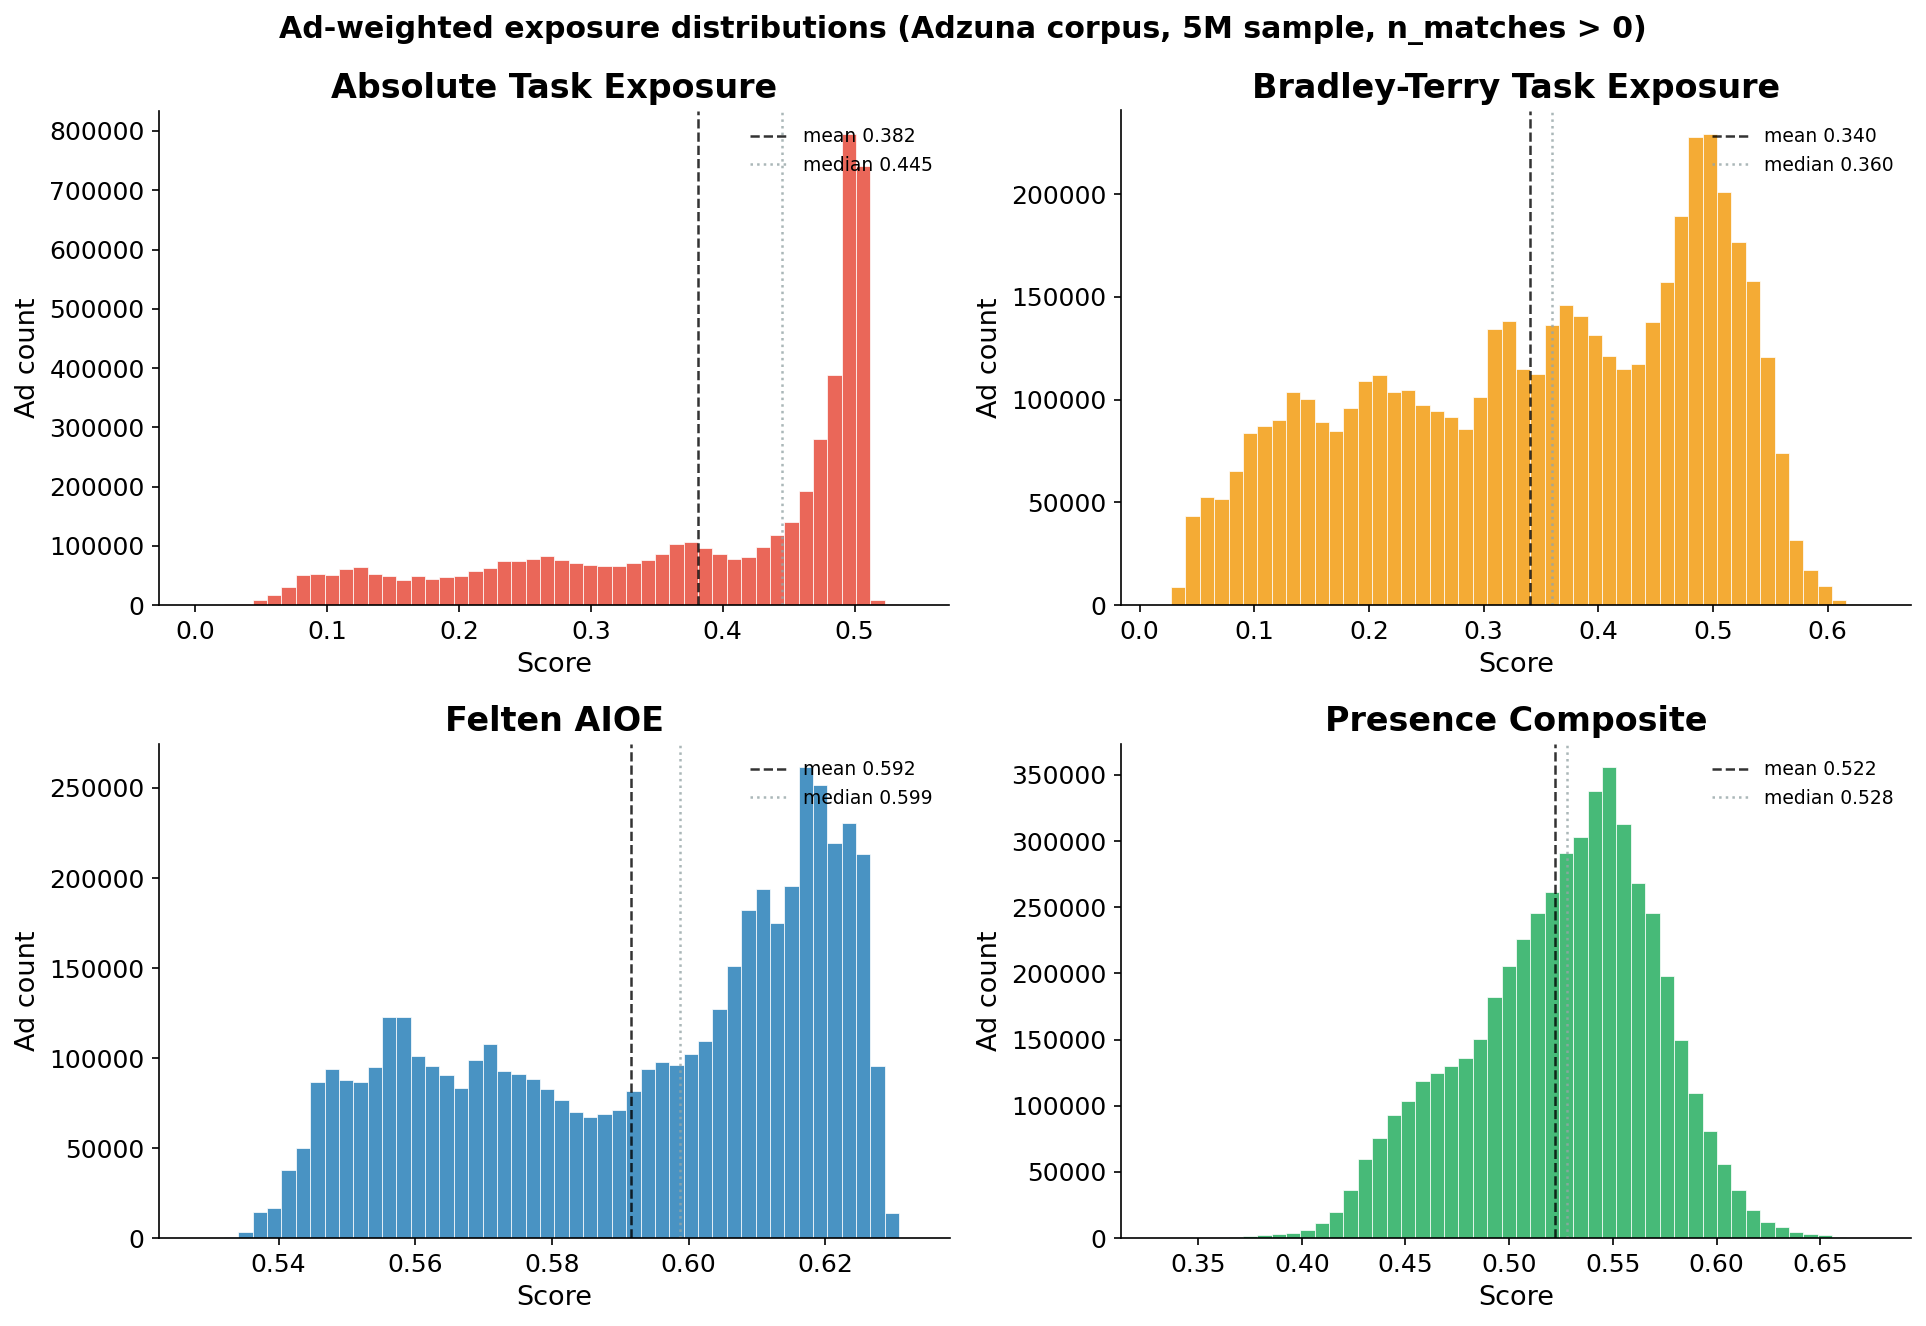

Saved /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/figures/ad_weighted_distribution.png


In [ ]:
N_BINS = 50

def _hist_bins(col: str, n_bins: int = N_BINS):
    lo, hi = con.execute(f"SELECT MIN({col}), MAX({col}) FROM ad_exp WHERE n_matches > 0").fetchone()
    if lo is None or hi is None or lo == hi:
        return None, None, None
    width = (hi - lo) / n_bins
    counts = con.execute(f"""
      SELECT bin_idx, COUNT(*) AS n FROM (
        SELECT LEAST(CAST(({col} - {lo}) / {width} AS INTEGER), {n_bins - 1}) AS bin_idx
        FROM ad_exp WHERE n_matches > 0 AND {col} IS NOT NULL
      ) GROUP BY bin_idx ORDER BY bin_idx
    """).fetchdf()
    edges = np.linspace(lo, hi, n_bins + 1)
    centres = (edges[:-1] + edges[1:]) / 2
    heights = np.zeros(n_bins, dtype=float)
    heights[counts['bin_idx'].astype(int).values] = counts['n'].values
    return centres, heights, (lo, hi)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
hist_targets = [
    ('task_exposure_mean', 'Absolute Task Exposure', ACCENT),
    ('task_exposure_bt_mean', 'Bradley-Terry Task Exposure', ORANGE),
    ('felten_score', 'Felten AIOE', SECONDARY),
    ('presence_composite', 'Presence Composite', GREEN),
]
for ax, (col, label, color) in zip(axes.flat, hist_targets):
    centres, heights, span = _hist_bins(col)
    if centres is None:
        ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center'); continue
    width = centres[1] - centres[0]
    ax.bar(centres, heights, width=width, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    row = ad_dist[ad_dist.score == col].iloc[0]
    ax.axvline(row['mean'], color='black', linestyle='--', linewidth=1.2, alpha=0.8, label=f"mean {row['mean']:.3f}")
    ax.axvline(row['median'], color=GREY_MED, linestyle=':', linewidth=1.2, alpha=0.8, label=f"median {row['median']:.3f}")
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Score'); ax.set_ylabel('Ad count')
    ax.legend(frameon=False, loc='upper right', fontsize=9)
fig.suptitle('Ad-weighted exposure distributions (Adzuna corpus, 5M sample, n_matches > 0)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "ad_weighted_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR / 'ad_weighted_distribution.png'}")

## Section 6 — Vulnerability and augmentation quadrants

Canonical definition (used everywhere downstream):

- **High exposure** = top quartile (Q4) of `task_exposure_mean` at the
  relevant altitude.
- **Low presence** = bottom quartile (Q1) of `presence_composite` at the
  relevant altitude.
- **Low exposure** = bottom quartile (Q1) of `task_exposure_mean`.
- **High presence** = top quartile (Q4) of `presence_composite`.
- Thresholds are computed **separately** for occupations, ads, and LADs — we
  never apply occupation-level thresholds to an ad- or LAD-level frame.
- Quadrants describe the **corners** of the joint distribution:
  - **Vulnerable**  = high exposure × low presence
  - **Augmented**   = high exposure × high presence
  - **Resilient**   = low exposure × high presence
  - **Unchanged**   = low exposure × low presence
- The middle two quartiles of either axis fall into no quadrant.

This supersedes notebook 01's median-based quadrant scatter for any count or
share cited in the report.

In [ ]:
def _q_thresholds(df: pd.DataFrame, exp_col: str, pres_col: str) -> dict:
    return {
        'exp_q1': float(df[exp_col].quantile(0.25)),
        'exp_q3': float(df[exp_col].quantile(0.75)),
        'pres_q1': float(df[pres_col].quantile(0.25)),
        'pres_q3': float(df[pres_col].quantile(0.75)),
    }

def _quadrant_counts(df: pd.DataFrame, exp_col: str, pres_col: str) -> dict:
    t = _q_thresholds(df, exp_col, pres_col)
    high_exp = df[exp_col] >= t['exp_q3']
    low_exp  = df[exp_col] <= t['exp_q1']
    high_pres = df[pres_col] >= t['pres_q3']
    low_pres  = df[pres_col] <= t['pres_q1']
    counts = {
        'vulnerable': int((high_exp & low_pres).sum()),
        'augmented':  int((high_exp & high_pres).sum()),
        'resilient':  int((low_exp & high_pres).sum()),
        'unchanged':  int((low_exp & low_pres).sum()),
    }
    return {'thresholds': t, 'counts': counts}

# Default to the absolute task-exposure variant for headline numbers; the BT
# variant is computed in parallel below.
exp_col = 'task_exposure_mean'
pres_col = 'presence_composite'

# --- 1. Occupations -------------------------------------------------------
occ_q = _quadrant_counts(onet_df, exp_col, pres_col)

# --- 2. Ads (via DuckDB; thresholds computed first, then counts) ----------
ad_thresh = con.execute(f"""
  SELECT QUANTILE_CONT({exp_col},  0.25) AS exp_q1,
         QUANTILE_CONT({exp_col},  0.75) AS exp_q3,
         QUANTILE_CONT({pres_col}, 0.25) AS pres_q1,
         QUANTILE_CONT({pres_col}, 0.75) AS pres_q3
  FROM ad_exp WHERE n_matches > 0
""").fetchone()
ad_thresholds = dict(zip(['exp_q1', 'exp_q3', 'pres_q1', 'pres_q3'], ad_thresh))
ad_quad = con.execute(f"""
  SELECT
    COUNT(*) FILTER (WHERE {exp_col}  >= {ad_thresholds['exp_q3']}
                       AND {pres_col} <= {ad_thresholds['pres_q1']}) AS vulnerable,
    COUNT(*) FILTER (WHERE {exp_col}  >= {ad_thresholds['exp_q3']}
                       AND {pres_col} >= {ad_thresholds['pres_q3']}) AS augmented,
    COUNT(*) FILTER (WHERE {exp_col}  <= {ad_thresholds['exp_q1']}
                       AND {pres_col} >= {ad_thresholds['pres_q3']}) AS resilient,
    COUNT(*) FILTER (WHERE {exp_col}  <= {ad_thresholds['exp_q1']}
                       AND {pres_col} <= {ad_thresholds['pres_q1']}) AS unchanged,
    COUNT(*) AS total
  FROM ad_exp WHERE n_matches > 0
""").fetchone()
ad_q = {
    'thresholds': {k: float(v) for k, v in ad_thresholds.items()},
    'counts': {'vulnerable': int(ad_quad[0]), 'augmented': int(ad_quad[1]),
               'resilient': int(ad_quad[2]), 'unchanged': int(ad_quad[3])},
    'total': int(ad_quad[4]),
}

# --- 3. LADs --------------------------------------------------------------
lad_q = _quadrant_counts(geo_df, exp_col, pres_col)

# Aggregated counts table
def _row(unit: str, total: int, q: dict) -> dict:
    c = q['counts']
    return {
        'unit': unit, 'total': total,
        'vulnerable_n': c['vulnerable'], 'vulnerable_pct': c['vulnerable'] / total,
        'augmented_n':  c['augmented'],  'augmented_pct':  c['augmented'] / total,
        'resilient_n':  c['resilient'],  'resilient_pct':  c['resilient'] / total,
        'unchanged_n':  c['unchanged'],  'unchanged_pct':  c['unchanged'] / total,
    }
quad_counts = pd.DataFrame([
    _row('occupations', len(onet_df), occ_q),
    _row('ads',         ad_q['total'], ad_q),
    _row('lads',        len(geo_df),  lad_q),
])
quad_counts.to_csv(TABLES_DIR / "quadrant_counts.csv", index=False)
print("Canonical quadrant counts (Q4 exposure x Q1/Q4 presence):")
print(quad_counts.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# By major group, count occupations per quadrant -------------------------
def _label(row, t):
    high_e, low_e = row[exp_col] >= t['exp_q3'], row[exp_col] <= t['exp_q1']
    high_p, low_p = row[pres_col] >= t['pres_q3'], row[pres_col] <= t['pres_q1']
    if high_e and low_p:  return 'vulnerable'
    if high_e and high_p: return 'augmented'
    if low_e and high_p:  return 'resilient'
    if low_e and low_p:   return 'unchanged'
    return 'middle'
onet_df['_quadrant'] = onet_df.apply(lambda r: _label(r, occ_q['thresholds']), axis=1)
quad_by_group = onet_df.pivot_table(
    index='major_group', columns='_quadrant', values='onet_code', aggfunc='count', fill_value=0,
).reset_index()
quad_by_group.columns.name = None
# Ensure every quadrant column exists even if absent in data.
for col in ['vulnerable', 'augmented', 'resilient', 'unchanged', 'middle']:
    if col not in quad_by_group.columns:
        quad_by_group[col] = 0
quad_by_group['total'] = quad_by_group[['vulnerable', 'augmented', 'resilient', 'unchanged', 'middle']].sum(axis=1)
quad_by_group = quad_by_group[['major_group', 'total', 'vulnerable', 'augmented', 'resilient', 'unchanged', 'middle']]
quad_by_group.to_csv(TABLES_DIR / "quadrant_by_major_group.csv", index=False)
print("\nOccupations per quadrant by major group:")
print(quad_by_group.to_string(index=False))

# Augmented occupations (full list with scores) --------------------------
aug = onet_df[onet_df['_quadrant'] == 'augmented'][[
    'onet_code', 'title', 'major_group',
    'task_exposure_mean', 'task_exposure_bt_mean',
    'presence_composite', 'presence_physical',
    'presence_emotional', 'presence_creative', 'felten_score',
]].sort_values('task_exposure_mean', ascending=False)
aug.to_csv(TABLES_DIR / "augmented_occupations.csv", index=False)
print(f"\nAugmented occupations (high exposure x high presence): {len(aug)} entries")
print(aug.head(15).to_string(index=False, float_format=lambda v: f'{v:.3f}'))

Canonical quadrant counts (Q4 exposure x Q1/Q4 presence):
       unit   total  vulnerable_n  vulnerable_pct  augmented_n  augmented_pct  resilient_n  resilient_pct  unchanged_n  unchanged_pct
occupations     861            31          0.0360           68         0.0790           16         0.0186          110         0.1278
        ads 4997227        150719          0.0302       382335         0.0765        48253         0.0097       748985         0.1499
       lads     373             3          0.0080           48         0.1287            8         0.0214           49         0.1314

Occupations per quadrant by major group:
                      major_group  total  vulnerable  augmented  resilient  unchanged  middle
       Architecture & Engineering     55           0          9          0          0      46
      Arts, Design, Entertainment     38           0          3          0          0      35
      Building & Grounds Cleaning      8           0          0          0        

### Quadrant counts panel

Three rows (occupations / ads / LADs) by four bars each. Each panel speaks
to a different denominator so the bar heights are deliberately not
comparable across rows; the headline value is the share, annotated on each
bar.

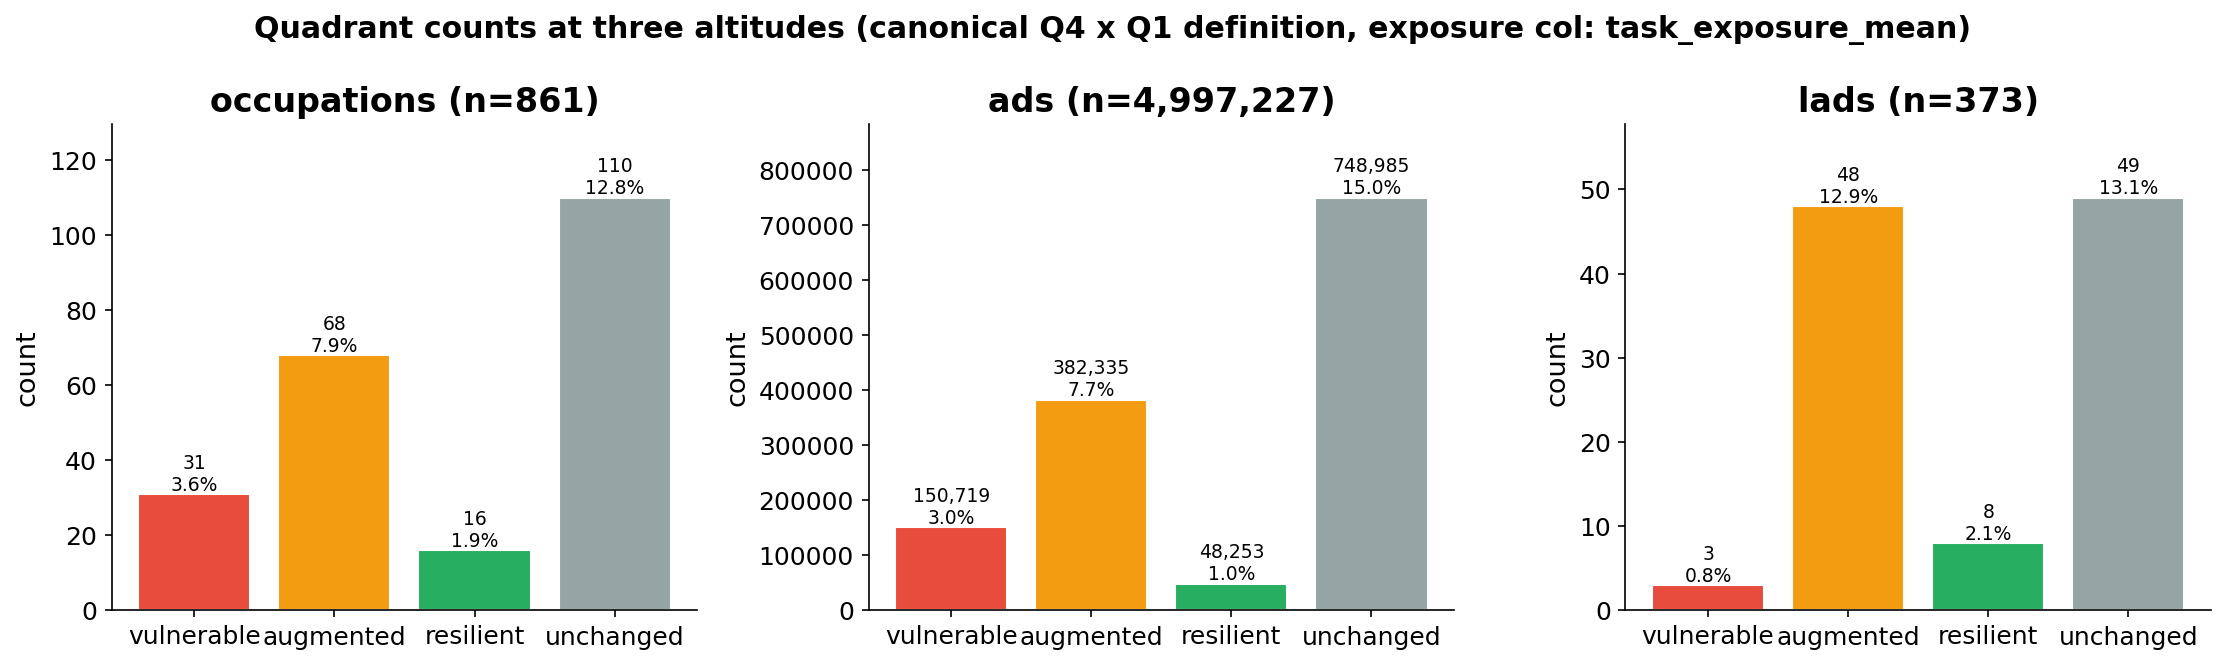

Saved /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/figures/quadrant_counts_panel.png

share_occupations_vulnerable = 0.0360
share_ads_vulnerable         = 0.0302
share_lads_vulnerable        = 0.0080
n_augmented_occupations      = 68


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
quad_order = ['vulnerable', 'augmented', 'resilient', 'unchanged']
quad_colors = {'vulnerable': ACCENT, 'augmented': ORANGE, 'resilient': GREEN, 'unchanged': GREY_MED}
units = [
    ('occupations', occ_q['counts'], len(onet_df)),
    ('ads',         ad_q['counts'],  ad_q['total']),
    ('lads',        lad_q['counts'], len(geo_df)),
]
for ax, (unit, counts, total) in zip(axes, units):
    heights = [counts[q] for q in quad_order]
    bars = ax.bar(quad_order, heights, color=[quad_colors[q] for q in quad_order],
                  edgecolor='white', linewidth=1)
    ax.set_title(f"{unit} (n={total:,})", fontweight='bold')
    ax.set_ylabel('count')
    for bar, h in zip(bars, heights):
        share = h / total
        ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:,}\n{share:.1%}',
                ha='center', va='bottom', fontsize=9)
    ax.margins(y=0.18)
fig.suptitle(f'Quadrant counts at three altitudes (canonical Q4 x Q1 definition, exposure col: {exp_col})',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "quadrant_counts_panel.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR / 'quadrant_counts_panel.png'}")

# Headline scalars
n_occ = len(onet_df); n_lad = len(geo_df); n_ad_total = ad_q['total']
topline_numbers['quadrants'] = {
    'definition': 'Q4 exposure x Q1 presence; thresholds computed at each altitude separately on task_exposure_mean and presence_composite.',
    'occupation_thresholds': occ_q['thresholds'],
    'ad_thresholds': ad_q['thresholds'],
    'lad_thresholds': lad_q['thresholds'],
    'share_occupations_vulnerable': occ_q['counts']['vulnerable'] / n_occ,
    'share_ads_vulnerable':         ad_q['counts']['vulnerable'] / n_ad_total,
    'share_lads_vulnerable':        lad_q['counts']['vulnerable'] / n_lad,
    'share_occupations_augmented':  occ_q['counts']['augmented']  / n_occ,
    'share_ads_augmented':          ad_q['counts']['augmented']  / n_ad_total,
    'share_lads_augmented':         lad_q['counts']['augmented']  / n_lad,
    'n_augmented_occupations':      occ_q['counts']['augmented'],
}
print(f"\nshare_occupations_vulnerable = {topline_numbers['quadrants']['share_occupations_vulnerable']:.4f}")
print(f"share_ads_vulnerable         = {topline_numbers['quadrants']['share_ads_vulnerable']:.4f}")
print(f"share_lads_vulnerable        = {topline_numbers['quadrants']['share_lads_vulnerable']:.4f}")
print(f"n_augmented_occupations      = {topline_numbers['quadrants']['n_augmented_occupations']}")

## Section 5 — Geography beyond maps

Tabular versions of the geography that the maps in notebook 02 already
visualise. Population: the Adzuna corpus (via the 5M sample), filtered to
ads with a LAD22CD. The London-vs-rest table mirrors the
README's headline comparison; nations (England/Scotland/Wales/Northern
Ireland) are derived from `LAD22CD` prefixes. A proper ITL1-region breakdown
would require an ONS lookup that is not part of this repository and is
stubbed below as deferred.

Top 20 LADs (absolute):
          LAD22NM       country_uk  n_ads  task_exposure_mean
   City of London           London  66194              0.4643
   Waltham Forest           London  12695              0.4345
        Islington           London  22386              0.4332
          Hackney           London  12941              0.4313
       Manchester   England (rest) 120101              0.4300
          Belfast Northern Ireland  24667              0.4252
        Stevenage   England (rest)   3019              0.4197
      Westminster           London  77318              0.4173
            Leeds   England (rest)  64123              0.4149
         Rushmoor   England (rest)   5026              0.4126
       Birmingham   England (rest)  94770              0.4112
    Malvern Hills   England (rest)   4772              0.4099
     Glasgow City         Scotland  48557              0.4087
          Watford   England (rest)   4170              0.4011
          Cardiff            Wales  30182     

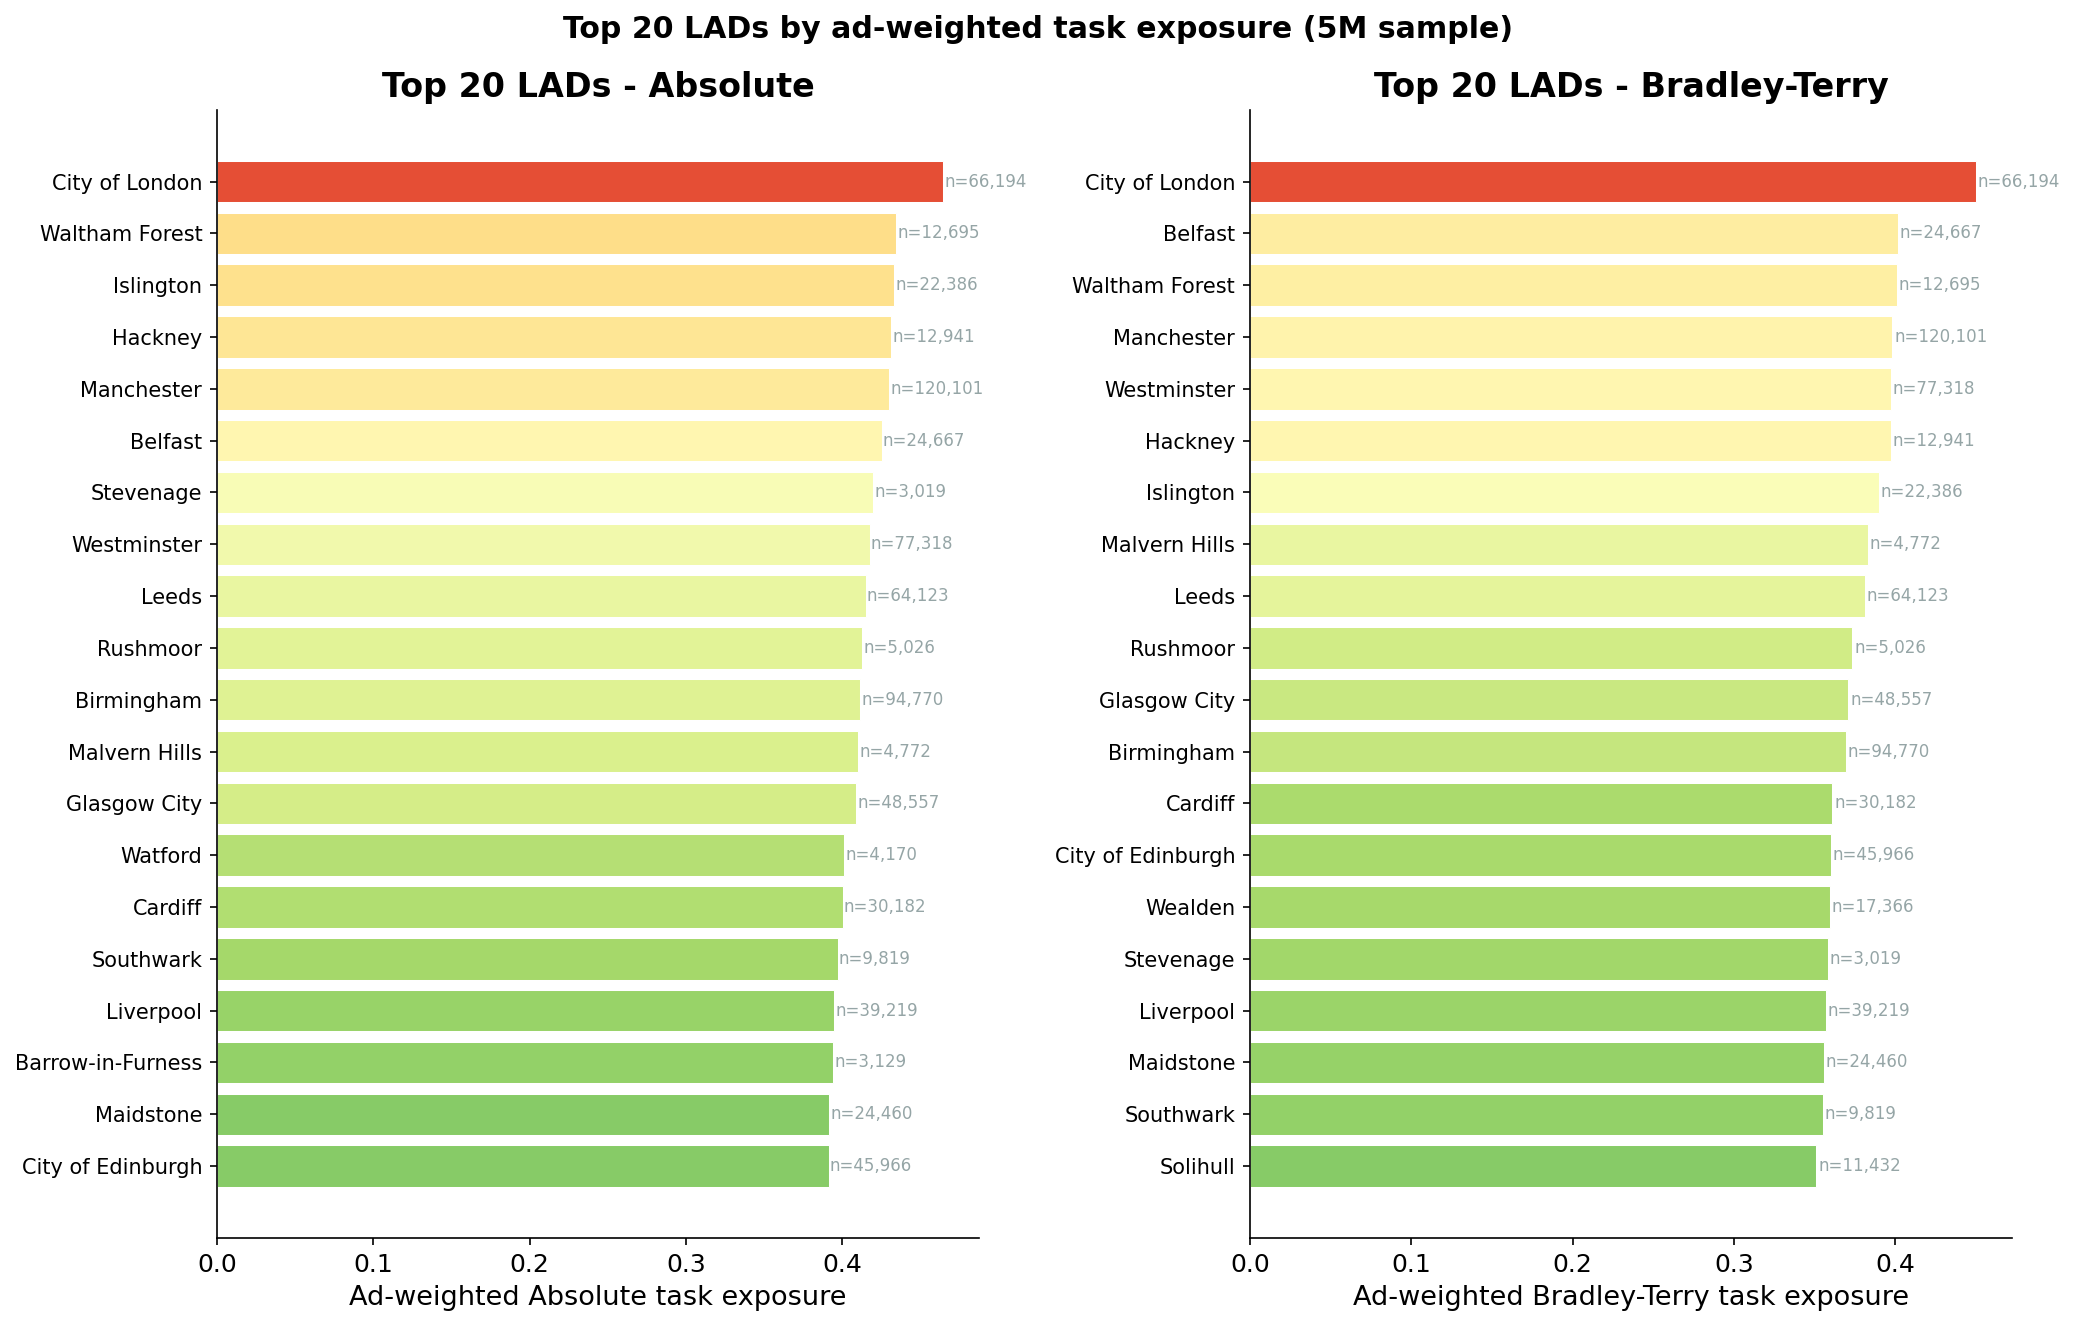

Saved /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/figures/top20_lads_tabular.png



london_share_of_all_high_exposure_ads = 0.1066
within_london_high_exposure_rate      = 0.3233
london_share_of_all_ads               = 0.0824
top_lad                               = City of London (E09000001, n_ads=66,194)


In [ ]:
def _nation_of(lad: str) -> str:
    if pd.isna(lad): return 'unknown'
    p = lad[:3]
    if p == 'E09': return 'London'
    if p[0] == 'E': return 'England (rest)'
    if p[0] == 'W': return 'Wales'
    if p[0] == 'S': return 'Scotland'
    if p[0] == 'N': return 'Northern Ireland'
    return 'unknown'

geo_df['country_uk'] = geo_df['LAD22CD'].map(_nation_of)

# --- Top/bottom 20 LADs --------------------------------------------------
for key, sv in SCORE_VARIANTS.items():
    col = sv['col']
    cols_out = ['LAD22CD', 'LAD22NM', 'country_uk', 'n_ads', col, 'presence_composite']
    top = geo_df.sort_values(col, ascending=False).head(20)[cols_out].reset_index(drop=True)
    bot = geo_df[geo_df['n_ads'] > 0].sort_values(col, ascending=True).head(20)[cols_out].reset_index(drop=True)
    top.to_csv(TABLES_DIR / f"top20_lads_by_task_exposure_{key}.csv", index=False)
    bot.to_csv(TABLES_DIR / f"bottom20_lads_by_task_exposure_{key}.csv", index=False)
print("Top 20 LADs (absolute):")
print(geo_df.sort_values('task_exposure_mean', ascending=False)
      .head(20)[['LAD22NM', 'country_uk', 'n_ads', 'task_exposure_mean']]
      .to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# --- London vs Rest of England vs nations -------------------------------
def _ad_weighted_mean(g: pd.DataFrame, col: str) -> float:
    w = g['n_ads_with_scores'].astype(float)
    if w.sum() == 0: return float('nan')
    return float((g[col].astype(float) * w).sum() / w.sum())

groups = []
for nation, sub in geo_df.groupby('country_uk', sort=False):
    row = {
        'country_uk': nation,
        'n_lads': int(len(sub)),
        'n_ads': int(sub['n_ads'].sum()),
        'n_ads_with_scores': int(sub['n_ads_with_scores'].sum()),
    }
    for col in ['task_exposure_mean', 'task_exposure_bt_mean', 'felten_score',
                'presence_composite', 'presence_physical']:
        row[f'{col}_ad_w'] = _ad_weighted_mean(sub, col)
    groups.append(row)
lvr = pd.DataFrame(groups)
# Preferred ordering for the report
order = ['London', 'England (rest)', 'Scotland', 'Wales', 'Northern Ireland']
lvr['_o'] = lvr['country_uk'].map({n: i for i, n in enumerate(order)}).fillna(99)
lvr = lvr.sort_values('_o').drop(columns='_o').reset_index(drop=True)
lvr.to_csv(TABLES_DIR / "london_vs_rest.csv", index=False)
print("\nLondon vs rest of UK (ad-weighted within each nation):")
print(lvr.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# --- Regional summary (ITL1) deferred ---------------------------------
(TABLES_DIR / "regional_summary.csv").write_text(
    "status,reason\n"
    "deferred,\"Requires ONS LAD-to-ITL1 region lookup; not present in repo. "
    "Add a lookup CSV at store/inputs/lad22_to_itl1.csv and rebuild this table.\"\n"
)

# --- Top 20 LADs ranked bar chart (two panels, absolute + BT) -----------
fig, axes = plt.subplots(1, 2, figsize=(14, 9))
for ax, (key, sv) in zip(axes, SCORE_VARIANTS.items()):
    col = sv['col']
    top = geo_df.sort_values(col, ascending=False).head(20).sort_values(col, ascending=True)
    norm = (top[col] - top[col].min()) / (top[col].max() - top[col].min() + 1e-9)
    colors = plt.cm.RdYlGn_r(norm * 0.6 + 0.25)
    ax.barh(np.arange(len(top)), top[col], color=colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(np.arange(len(top)))
    ax.set_yticklabels(top['LAD22NM'], fontsize=10)
    ax.set_xlabel(f'Ad-weighted {sv["label_short"]} task exposure')
    ax.set_title(f'Top 20 LADs - {sv["label_short"]}', fontweight='bold')
    for i, (_, r) in enumerate(top.iterrows()):
        ax.text(r[col] + (top[col].max() - top[col].min())*0.01, i,
                f"n={int(r['n_ads']):,}", fontsize=8, va='center', color=GREY_MED)
fig.suptitle('Top 20 LADs by ad-weighted task exposure (5M sample)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "top20_lads_tabular.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR / 'top20_lads_tabular.png'}")

# --- Geography scalars --------------------------------------------------
# Two distinct things the report can say about London. Keep them separate so
# the report cannot accidentally conflate them:
#
#   - **london_share_of_all_high_exposure_ads** = London's count of high-
#     exposure ads divided by the corpus-wide count of high-exposure ads.
#     "How much of the high-exposure pool comes from London?" If this
#     exceeds London's share of all ads, London is over-represented at the
#     high end.
#   - **within_london_high_exposure_rate** = London's count of high-exposure
#     ads divided by London's total ads. "What share of London ads are
#     high-exposure?" Compare directly with the corpus-wide Q3 share (0.25)
#     and with the within-group rates from Section 4.
ad_q3 = ad_q['thresholds']['exp_q3']  # ad-level Q3 from Section 6
london_counts = con.execute(f"""
  WITH joined AS (
    SELECT e.{exp_col} AS te, a.LAD22CD AS lad
    FROM ad_exp e LEFT JOIN adz.ads a ON e.ad_id = a.id
    WHERE e.n_matches > 0
  )
  SELECT
    COUNT(*) FILTER (WHERE lad LIKE 'E09%')                    AS london_total,
    COUNT(*) FILTER (WHERE te >= {ad_q3} AND lad LIKE 'E09%')  AS london_high,
    COUNT(*) FILTER (WHERE te >= {ad_q3})                      AS corpus_high
  FROM joined
""").fetchone()
london_total, london_high, corpus_high = london_counts
london_share_of_all_high = (london_high / corpus_high) if corpus_high else float('nan')
within_london_high_rate  = (london_high / london_total) if london_total else float('nan')
london_share_of_all_ads  = (london_total / n_ads_total)  # for context — does London punch above its weight?

top_lad = geo_df.sort_values(exp_col, ascending=False).iloc[0]

topline_numbers['geography'] = {
    'top_lad_by_task_exposure': {
        'LAD22NM': str(top_lad['LAD22NM']),
        'LAD22CD': str(top_lad['LAD22CD']),
        'task_exposure_mean': float(top_lad['task_exposure_mean']),
        'n_ads': int(top_lad['n_ads']),
    },
    'london_share_of_all_high_exposure_ads': float(london_share_of_all_high),
    'within_london_high_exposure_rate':       float(within_london_high_rate),
    'london_share_of_all_ads':                float(london_share_of_all_ads),
    'london_n_ads':                            int(london_total),
    'london_n_high_exposure_ads':              int(london_high),
    'corpus_n_high_exposure_ads':              int(corpus_high),
    'note_itl1_regional': 'deferred (needs ONS LAD-to-ITL1 lookup)',
}
print(f"\nlondon_share_of_all_high_exposure_ads = {london_share_of_all_high:.4f}")
print(f"within_london_high_exposure_rate      = {within_london_high_rate:.4f}")
print(f"london_share_of_all_ads               = {london_share_of_all_ads:.4f}")
print(f"top_lad                               = {top_lad['LAD22NM']} ({top_lad['LAD22CD']}, n_ads={int(top_lad['n_ads']):,})")

## Section 8 — Metric robustness and disagreement

Where the scoring methods agree (convergent validity) and where they
disagree (cases the report should call out explicitly). Population:
occupations, throughout. The external-benchmark comparison (8d) is stubbed
as deferred since the Eloundou and Anthropic Economic Index occupation-level
tables are not in this repo.

### 8a. Cross-metric rank correlations

Spearman rho matrix (occupation level):
                                      felten_score  task_exposure_mean  task_exposure_importance_weighted  task_exposure_bt_mean  task_exposure_bt_importance_weighted  presence_physical  presence_emotional  presence_creative  presence_composite
felten_score                                 1.000               0.868                              0.869                  0.897                                 0.896             -0.727               0.493              0.720               0.304
task_exposure_mean                           0.868               1.000                              0.998                  0.929                                 0.929             -0.595               0.514              0.728               0.374
task_exposure_importance_weighted            0.869               0.998                              1.000                  0.930                                 0.929             -0.597               0.513              0.730 

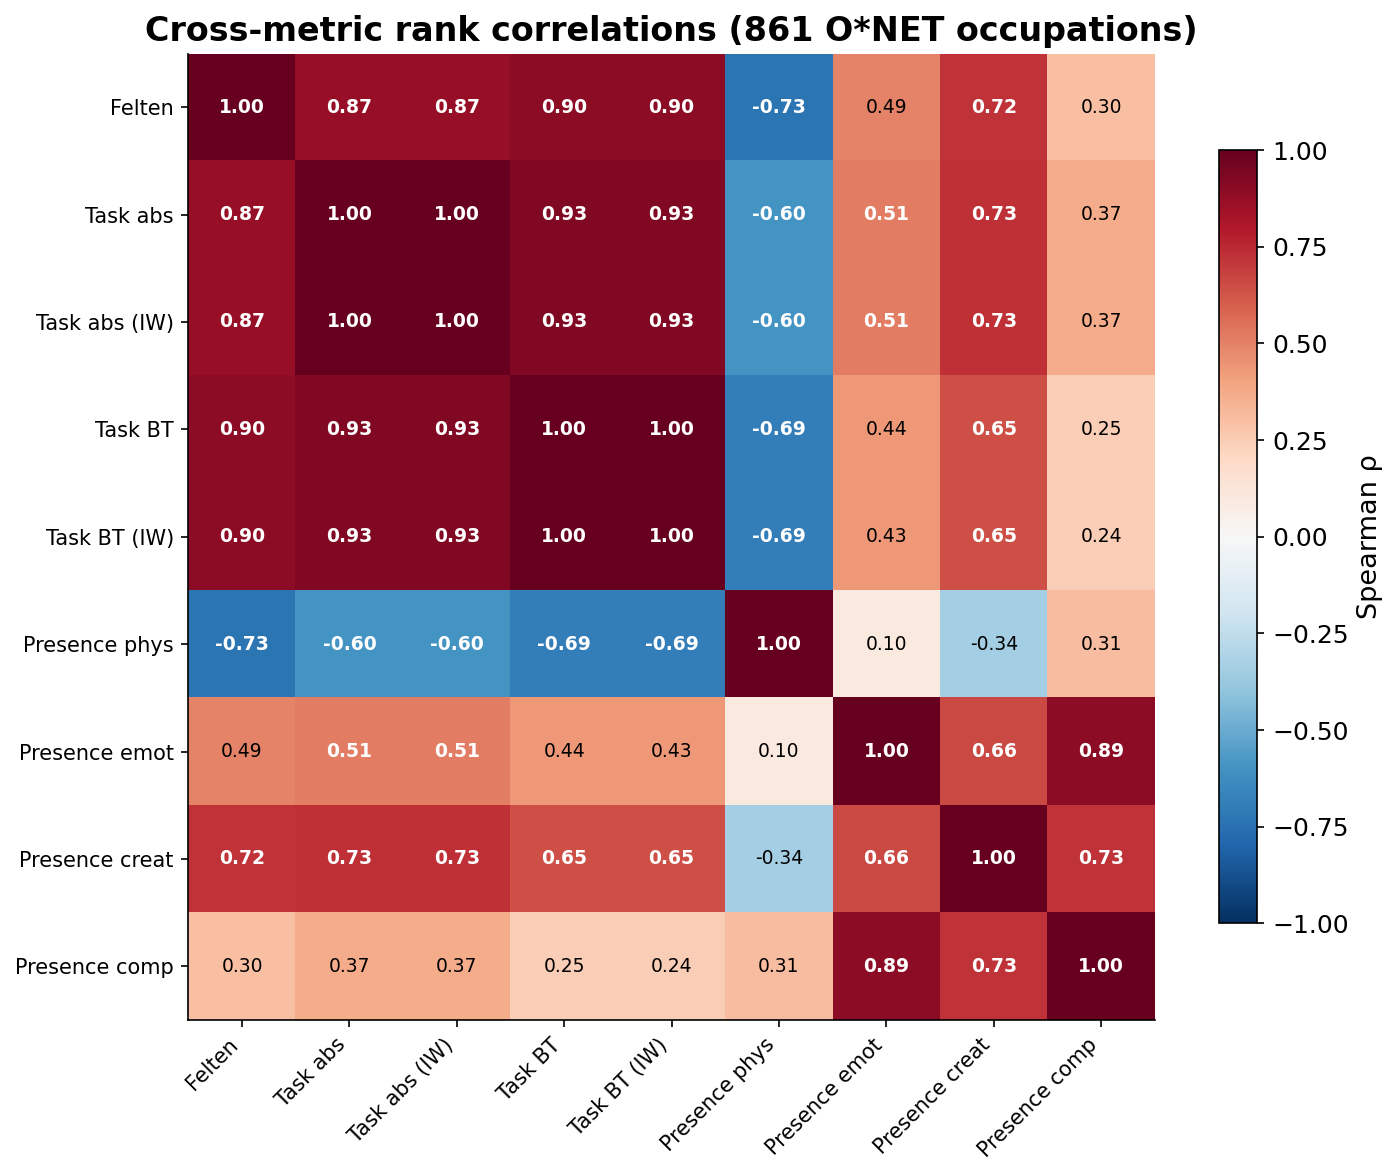

Saved /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/figures/correlation_matrix_extended.png


In [ ]:
from scipy.stats import spearmanr  # local import keeps the global preamble tidy

corr_score_cols = [
    'felten_score',
    'task_exposure_mean', 'task_exposure_importance_weighted',
    'task_exposure_bt_mean', 'task_exposure_bt_importance_weighted',
    'presence_physical', 'presence_emotional', 'presence_creative', 'presence_composite',
]
corr_labels = {
    'felten_score': 'Felten',
    'task_exposure_mean': 'Task abs',
    'task_exposure_importance_weighted': 'Task abs (IW)',
    'task_exposure_bt_mean': 'Task BT',
    'task_exposure_bt_importance_weighted': 'Task BT (IW)',
    'presence_physical': 'Presence phys',
    'presence_emotional': 'Presence emot',
    'presence_creative': 'Presence creat',
    'presence_composite': 'Presence comp',
}

rho_matrix = pd.DataFrame(index=corr_score_cols, columns=corr_score_cols, dtype=float)
for a in corr_score_cols:
    for b in corr_score_cols:
        rho, _ = spearmanr(onet_df[a], onet_df[b])
        rho_matrix.loc[a, b] = float(rho)
rho_matrix.to_csv(TABLES_DIR / "cross_metric_correlations.csv", index=True)
print("Spearman rho matrix (occupation level):")
print(rho_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(rho_matrix.values.astype(float), cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_score_cols)))
ax.set_yticks(range(len(corr_score_cols)))
ax.set_xticklabels([corr_labels[c] for c in corr_score_cols], rotation=45, ha='right', fontsize=10)
ax.set_yticklabels([corr_labels[c] for c in corr_score_cols], fontsize=10)
for i in range(len(corr_score_cols)):
    for j in range(len(corr_score_cols)):
        v = rho_matrix.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.5 else 'black',
                fontweight='bold' if abs(v) > 0.5 else 'normal')
plt.colorbar(im, ax=ax, shrink=0.8, label='Spearman ρ')
ax.set_title('Cross-metric rank correlations (861 O*NET occupations)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_matrix_extended.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR / 'correlation_matrix_extended.png'}")

### 8b. Importance-weighted vs unweighted task exposure

How much does importance-weighting change the per-occupation conclusion? If
rho is near 1 and rank shifts are small, the two are interchangeable; if not,
the report should specify which variant the cited number uses.

absolute: spearman(task_exposure_mean vs task_exposure_importance_weighted) = 0.9984
bt: spearman(task_exposure_bt_mean vs task_exposure_bt_importance_weighted) = 0.9995


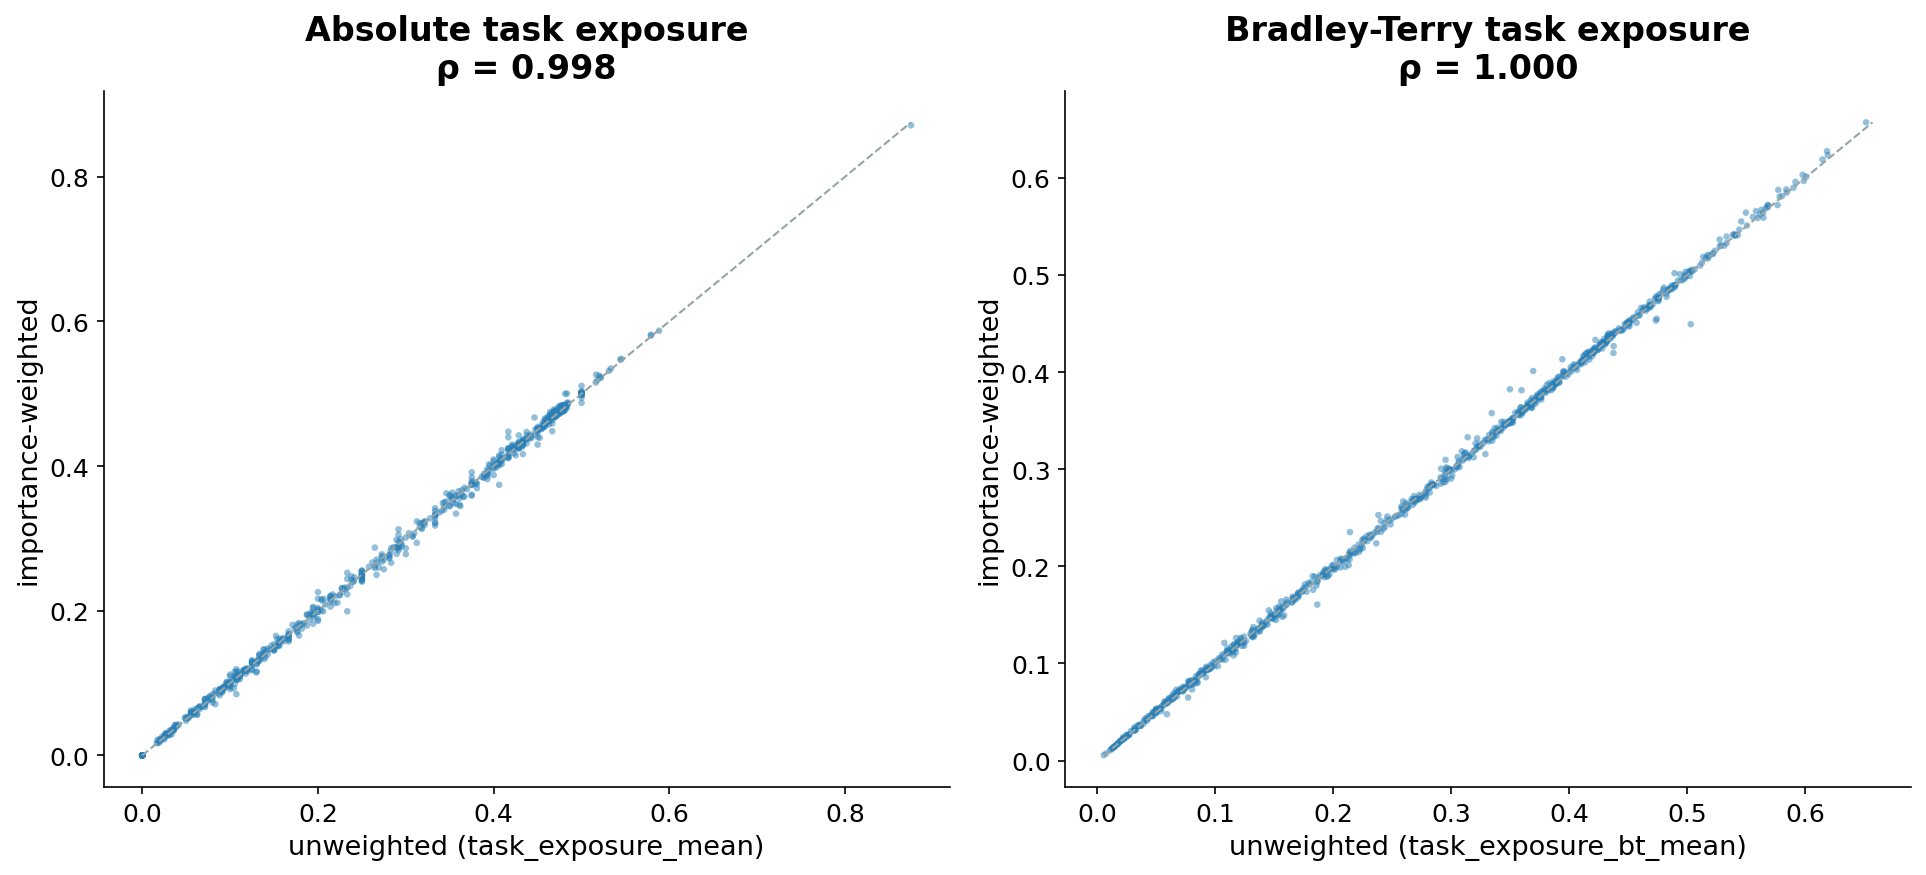

Saved /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/figures/importance_weighting_scatter.png


In [ ]:
movers_rows = []
for variant_key, mean_col, iw_col in [
    ('absolute', 'task_exposure_mean', 'task_exposure_importance_weighted'),
    ('bt',       'task_exposure_bt_mean', 'task_exposure_bt_importance_weighted'),
]:
    rho, _ = spearmanr(onet_df[mean_col], onet_df[iw_col])
    print(f"{variant_key}: spearman({mean_col} vs {iw_col}) = {rho:.4f}")

    rk_u = onet_df[mean_col].rank(ascending=False)
    rk_w = onet_df[iw_col].rank(ascending=False)
    shift = (rk_u - rk_w).abs()
    top_shift = pd.DataFrame({
        'variant': variant_key,
        'onet_code': onet_df['onet_code'],
        'title': onet_df['title'],
        'major_group': onet_df['major_group'],
        'rank_unweighted': rk_u.astype(int),
        'rank_weighted': rk_w.astype(int),
        'rank_shift': shift.astype(int),
        'unweighted': onet_df[mean_col],
        'weighted': onet_df[iw_col],
    }).nlargest(20, 'rank_shift')
    movers_rows.append(top_shift)
movers = pd.concat(movers_rows, ignore_index=True)
movers.to_csv(TABLES_DIR / "importance_weighting_movers.csv", index=False)

# Scatter: unweighted vs weighted for both variants
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (label, mean_col, iw_col) in zip(axes, [
    ('Absolute task exposure', 'task_exposure_mean', 'task_exposure_importance_weighted'),
    ('Bradley-Terry task exposure', 'task_exposure_bt_mean', 'task_exposure_bt_importance_weighted'),
]):
    ax.scatter(onet_df[mean_col], onet_df[iw_col], s=10, alpha=0.5, color=SECONDARY, edgecolor='none')
    lo, hi = float(min(onet_df[mean_col].min(), onet_df[iw_col].min())), \
             float(max(onet_df[mean_col].max(), onet_df[iw_col].max()))
    ax.plot([lo, hi], [lo, hi], color=GREY_MED, linestyle='--', linewidth=1)
    rho, _ = spearmanr(onet_df[mean_col], onet_df[iw_col])
    ax.set_xlabel(f'unweighted ({mean_col})'); ax.set_ylabel(f'importance-weighted')
    ax.set_title(f'{label}\nρ = {rho:.3f}', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "importance_weighting_scatter.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR / 'importance_weighting_scatter.png'}")

### 8c. Concrete metric disagreement cases

Four small case lists (10 each). Each case is a place where a different
scoring method would tell the report a meaningfully different story.

In [ ]:
def _quartile_flags(df: pd.DataFrame, col: str) -> tuple[pd.Series, pd.Series]:
    q1 = df[col].quantile(0.25); q3 = df[col].quantile(0.75)
    return df[col] <= q1, df[col] >= q3

felten_low, felten_high = _quartile_flags(onet_df, 'felten_score')
task_low,   task_high   = _quartile_flags(onet_df, 'task_exposure_mean')

case_cols = ['onet_code', 'title', 'major_group',
             'felten_score', 'task_exposure_mean', 'task_exposure_bt_mean',
             'presence_composite']

cases_high_felten_low_task = (onet_df[felten_high & task_low]
    .nsmallest(10, 'task_exposure_mean')
    .assign(case='high_felten_low_task')[['case'] + case_cols])
cases_high_task_low_felten = (onet_df[task_high & felten_low]
    .nlargest(10, 'task_exposure_mean')
    .assign(case='high_task_low_felten')[['case'] + case_cols])

# Absolute vs BT rank shifts
rk_abs = onet_df['task_exposure_mean'].rank(ascending=False)
rk_bt  = onet_df['task_exposure_bt_mean'].rank(ascending=False)
abs_vs_bt_shift = (rk_abs - rk_bt).abs()
top_disagree_abs_bt = (onet_df.assign(_shift=abs_vs_bt_shift)
    .nlargest(10, '_shift')
    .assign(case='abs_vs_bt_rank_shift')[['case'] + case_cols])

# Augmented quadrant subset (high exposure, high presence) - use Section 6 thresholds
case_augmented = (onet_df[onet_df['_quadrant'] == 'augmented']
    .nlargest(10, 'task_exposure_mean')
    .assign(case='high_exposure_high_presence')[['case'] + case_cols])

disagreement = pd.concat([
    cases_high_felten_low_task,
    cases_high_task_low_felten,
    top_disagree_abs_bt,
    case_augmented,
], ignore_index=True)
disagreement.to_csv(TABLES_DIR / "metric_disagreement_cases.csv", index=False)
print(f"\nDisagreement case list: {len(disagreement)} occupations across 4 cases")
print(disagreement[['case', 'title', 'felten_score', 'task_exposure_mean',
                    'task_exposure_bt_mean', 'presence_composite']]
      .to_string(index=False, float_format=lambda v: f'{v:.3f}'))


Disagreement case list: 20 occupations across 4 cases
                       case                                              title  felten_score  task_exposure_mean  task_exposure_bt_mean  presence_composite
       abs_vs_bt_rank_shift                                     Range Managers         0.581               0.500                  0.263               0.599
       abs_vs_bt_rank_shift    Legal Secretaries and Administrative Assistants         0.607               0.429                  0.564               0.449
       abs_vs_bt_rank_shift  Medical Secretaries and Administrative Assistants         0.609               0.433                  0.550               0.467
       abs_vs_bt_rank_shift                             Office Clerks, General         0.607               0.425                  0.512               0.428
       abs_vs_bt_rank_shift        Court Reporters and Simultaneous Captioners         0.601               0.393                  0.465               0.374
       ab

### 8d. External benchmark comparison

Deferred. The Eloundou et al. and Anthropic Economic Index occupation-level
tables are documented as external benchmarks but are not present in this
repo. To activate this section, drop the relevant CSV under
`store/inputs/external_benchmarks/` and rebuild.

In [ ]:
topline_numbers['robustness'] = {
    'rho_abs_vs_bt':  float(spearmanr(onet_df['task_exposure_mean'], onet_df['task_exposure_bt_mean'])[0]),
    'rho_abs_vs_felten': float(spearmanr(onet_df['task_exposure_mean'], onet_df['felten_score'])[0]),
    'rho_abs_vs_presence_phys': float(spearmanr(onet_df['task_exposure_mean'], onet_df['presence_physical'])[0]),
    'rho_abs_unweighted_vs_iw': float(spearmanr(onet_df['task_exposure_mean'], onet_df['task_exposure_importance_weighted'])[0]),
    'rho_bt_unweighted_vs_iw':  float(spearmanr(onet_df['task_exposure_bt_mean'], onet_df['task_exposure_bt_importance_weighted'])[0]),
    'external_benchmark': 'deferred',
}
print(f"\nrho_abs_vs_bt              = {topline_numbers['robustness']['rho_abs_vs_bt']:.4f}")
print(f"rho_abs_unweighted_vs_iw   = {topline_numbers['robustness']['rho_abs_unweighted_vs_iw']:.4f}")
print(f"rho_bt_unweighted_vs_iw    = {topline_numbers['robustness']['rho_bt_unweighted_vs_iw']:.4f}")


rho_abs_vs_bt              = 0.9294
rho_abs_unweighted_vs_iw   = 0.9984
rho_bt_unweighted_vs_iw    = 0.9995


## Sections 4 and 7 — Per-ad occupation assignment

Both ad-weighted occupational contribution (Section 4) and the 2022-vs-2025
temporal comparison (Section 7) need a per-ad "primary occupation" to roll
ads up to occupation or major-group level. We use the **top-rerank-score
match per ad** as the proxy (the spec endorses this). The `rank` column on
`reranked_matches.parquet` reflects the order at filter time, not the
rerank ordering, so we explicitly compute `ARG_MAX(onet_code, rerank_score)`
per ad.

We register `reranked_matches` and build a single derived table
`ad_primary` that every downstream cell reuses.

In [ ]:
RERANK_PATH = ROOT / "store/pipeline/production_5m/rerank_candidates/reranked_matches.parquet"
con.execute(f"CREATE OR REPLACE VIEW rerank AS SELECT * FROM read_parquet('{RERANK_PATH}')")

# Materialise the per-ad primary join so subsequent queries are fast. This
# table is ~5M rows; persisting it inside DuckDB's in-memory cache is fine.
con.execute("""
  CREATE OR REPLACE TABLE ad_primary AS
  WITH top_match AS (
    SELECT ad_id, ARG_MAX(onet_code, rerank_score) AS primary_onet
    FROM rerank GROUP BY ad_id
  )
  SELECT
    e.ad_id,
    e.n_matches,
    e.task_exposure_mean,
    e.task_exposure_bt_mean,
    e.felten_score,
    e.presence_composite,
    t.primary_onet,
    SUBSTR(t.primary_onet, 1, 2)::INTEGER AS primary_major_code,
    a.year,
    a.LAD22CD
  FROM ad_exp e
  LEFT JOIN top_match t ON e.ad_id = t.ad_id
  LEFT JOIN adz.ads a   ON e.ad_id = a.id
  WHERE e.n_matches > 0 AND t.primary_onet IS NOT NULL
""")
n_primary = con.execute("SELECT COUNT(*) FROM ad_primary").fetchone()[0]
print(f"ad_primary built: {n_primary:,} rows ({n_primary/n_ads_total:.4%} of analysed ads)")

ad_primary built: 4,997,227 rows (100.0000% of analysed ads)


## Section 4 — What kinds of work drive exposure

Distinguishes "which occupations score highest in O\*NET" (notebook 01) from
"which occupations supply the most high-exposure postings in the corpus"
(here). Both an occupation rank and a major-group breakdown are produced.
Population: Adzuna corpus (via the 5M random sample), ad-weighted.

In [ ]:
# --- 4.1 Major-group level --------------------------------------------
#
# Two distinct statistics that the report must not conflate:
#
#   - **high_exposure_rate** = within this major group, what share of *its*
#     ads are high-exposure (Q4). Answers: "is work in group X concentrated
#     in high-exposure roles?"
#   - **share_of_all_high_exposure_ads** = this major group's count of
#     high-exposure ads divided by the corpus-wide total of high-exposure
#     ads. Answers: "how much of the high-exposure pool does group X supply?"
#
# A group can have a high rate but a small share (small group, mostly
# high-exposure jobs) or a low rate but a large share (large group with a
# minority of high-exposure jobs). Both views are reported below; the
# scalars in `topline_numbers.json` carry both rankings separately.

ad_q3_abs = ad_q['thresholds']['exp_q3']  # ad-level Q3 from Section 6
total_high_ads = int(con.execute(
    f"SELECT COUNT(*) FROM ad_primary WHERE task_exposure_mean >= {ad_q3_abs}"
).fetchone()[0])

major_w = con.execute(f"""
  SELECT primary_major_code AS major_code,
         COUNT(*)             AS n_ads,
         SUM(CASE WHEN task_exposure_mean >= {ad_q3_abs} THEN 1 ELSE 0 END) AS n_high,
         AVG(task_exposure_mean)    AS mean_task_exposure,
         AVG(task_exposure_bt_mean) AS mean_task_exposure_bt,
         AVG(felten_score)          AS mean_felten,
         AVG(presence_composite)    AS mean_presence,
         AVG(CASE WHEN task_exposure_mean >= {ad_q3_abs} THEN 1 ELSE 0 END) AS high_exposure_rate
  FROM ad_primary GROUP BY primary_major_code ORDER BY n_ads DESC
""").fetchdf()
major_w['major_group'] = major_w['major_code'].map(ONET_MAJOR_NAMES)
major_w['share_of_all_high_exposure_ads'] = major_w['n_high'] / float(total_high_ads)
major_w = major_w[['major_code', 'major_group', 'n_ads', 'n_high',
                   'high_exposure_rate', 'share_of_all_high_exposure_ads',
                   'mean_task_exposure', 'mean_task_exposure_bt',
                   'mean_felten', 'mean_presence']]
major_w.to_csv(TABLES_DIR / "exposure_by_major_group_ad_weighted.csv", index=False)
print("Ad-weighted statistics by major group (top match):")
print(major_w.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f"\nTotal high-exposure ads (task_exposure_mean >= ad_q3 = {ad_q3_abs:.4f}): {total_high_ads:,}")
print("\nTop 5 by within-group high_exposure_rate:")
print(major_w.nlargest(5, 'high_exposure_rate')[['major_group', 'n_ads', 'n_high', 'high_exposure_rate']]
      .to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print("\nTop 5 by share_of_all_high_exposure_ads:")
print(major_w.nlargest(5, 'share_of_all_high_exposure_ads')[['major_group', 'n_ads', 'n_high', 'share_of_all_high_exposure_ads']]
      .to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# --- 4.2 Top 20 occupations by share of high-exposure ads -------------
# share_of_high_exposure = (# ads where top match is X AND task_exposure_mean >= ad_q3) / total_high_exposure_ads
occ_w = con.execute(f"""
  WITH agg AS (
    SELECT primary_onet AS onet_code,
           COUNT(*) AS n_ads_top_match,
           SUM(CASE WHEN task_exposure_mean >= {ad_q3_abs} THEN 1 ELSE 0 END) AS n_high,
           AVG(task_exposure_mean)    AS mean_task_exposure,
           AVG(task_exposure_bt_mean) AS mean_task_exposure_bt,
           AVG(presence_composite)    AS mean_presence
    FROM ad_primary GROUP BY primary_onet
  ),
  totals AS (
    SELECT SUM(n_high) AS total_high FROM agg
  )
  SELECT a.onet_code,
         a.n_ads_top_match,
         a.n_high,
         a.n_high / CAST(t.total_high AS DOUBLE) AS share_of_high_exposure_ads,
         a.mean_task_exposure,
         a.mean_task_exposure_bt,
         a.mean_presence
  FROM agg a, totals t ORDER BY share_of_high_exposure_ads DESC LIMIT 20
""").fetchdf()
# Attach titles + occupation-level scores for comparison
occ_w = occ_w.merge(onet_df[['onet_code', 'title', 'major_group',
                              'task_exposure_mean', 'task_exposure_bt_mean']]
                     .rename(columns={'task_exposure_mean': 'occ_task_exposure_mean',
                                      'task_exposure_bt_mean': 'occ_task_exposure_bt_mean'}),
                    on='onet_code', how='left')
occ_w = occ_w[['onet_code', 'title', 'major_group', 'n_ads_top_match', 'n_high',
                'share_of_high_exposure_ads',
                'mean_task_exposure', 'occ_task_exposure_mean',
                'mean_task_exposure_bt', 'occ_task_exposure_bt_mean',
                'mean_presence']]
occ_w.to_csv(TABLES_DIR / "top20_occupations_by_high_exposure_share.csv", index=False)
print("\nTop 20 occupations by share of high-exposure ads (top-match proxy):")
print(occ_w.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# --- 4.3 JSON scalars ---------------------------------------------------
# Two rankings, kept separate so the report cannot accidentally conflate them.
top_3_by_rate = major_w.nlargest(3, 'high_exposure_rate')
top_3_by_share = major_w.nlargest(3, 'share_of_all_high_exposure_ads')
top_5_by_share = major_w.nlargest(5, 'share_of_all_high_exposure_ads')

topline_numbers['ad_weighted_contribution'] = {
    'ad_q3_threshold_used': float(ad_q3_abs),
    'total_high_exposure_ads': total_high_ads,
    'top_3_major_groups_by_high_exposure_rate': [
        {'major_group': str(r['major_group']), 'rate': float(r['high_exposure_rate']),
         'n_ads': int(r['n_ads']), 'n_high': int(r['n_high'])}
        for _, r in top_3_by_rate.iterrows()
    ],
    'top_3_major_groups_by_share_of_all_high_exposure_ads': [
        {'major_group': str(r['major_group']), 'share_of_all_high': float(r['share_of_all_high_exposure_ads']),
         'n_high': int(r['n_high']), 'within_group_rate': float(r['high_exposure_rate'])}
        for _, r in top_3_by_share.iterrows()
    ],
    'share_of_all_high_exposure_ads_top_5_major_groups': float(top_5_by_share['share_of_all_high_exposure_ads'].sum()),
    'note': 'Major group assigned via top-rerank-score match per ad (proxy).',
}
print(f"\ntop 3 by within-group rate           = {[r['major_group'] for r in topline_numbers['ad_weighted_contribution']['top_3_major_groups_by_high_exposure_rate']]}")
print(f"top 3 by share of all high-exposure  = {[r['major_group'] for r in topline_numbers['ad_weighted_contribution']['top_3_major_groups_by_share_of_all_high_exposure_ads']]}")
print(f"top-5-groups share of all high       = {topline_numbers['ad_weighted_contribution']['share_of_all_high_exposure_ads_top_5_major_groups']:.4f}")

Ad-weighted statistics by major group (top match):
 major_code                       major_group  n_ads      n_high  high_exposure_rate  share_of_all_high_exposure_ads  mean_task_exposure  mean_task_exposure_bt  mean_felten  mean_presence
         11                        Management 696703 398420.0000              0.5719                          0.3189              0.4803                 0.4359       0.6115         0.5602
         15           Computer & Mathematical 466228 387650.0000              0.8315                          0.3103              0.4940                 0.5022       0.6163         0.5146
         43           Office & Administrative 424085  84417.0000              0.1991                          0.0676              0.4527                 0.4740       0.6051         0.4745
         25           Educational Instruction 397579   2194.0000              0.0055                          0.0018              0.4041                 0.3385       0.6016         0.5367
         

## Section 7 — 2022 vs 2025 compositional change

Exposure scores are fixed at O\*NET occupation level, so any change in
ad-weighted exposure between years is *purely compositional*: it reflects
the mix of occupations being advertised, not changes in AI capability.
Population: the Adzuna corpus (via random sampling). Corpus-wide quartile
thresholds are used so the two years are directly comparable.

Ad-weighted statistics by year:
 year   n_ads  mean_te_abs  median_te_abs  p90_te_abs  mean_te_bt  median_te_bt  mean_felten  mean_presence  share_high_abs
 2022 3285356       0.3814         0.4515      0.4985      0.3438        0.3677       0.5918         0.5203          0.2724
 2025 1711871       0.3820         0.4353      0.4966      0.3325        0.3484       0.5913         0.5249          0.2071

Major group: share of high-exposure ads, 2022 vs 2025:
 major_code                       major_group  share_high_2022  share_high_2025   delta
         11                        Management          +0.5956          +0.5253 -0.0703
         13              Business & Financial          +0.6132          +0.5394 -0.0738
         15           Computer & Mathematical          +0.8326          +0.8276 -0.0051
         17        Architecture & Engineering          +0.1619          +0.1499 -0.0119
         19   Life, Physical & Social Science          +0.3408          +0.2996 -0.0412
         21 

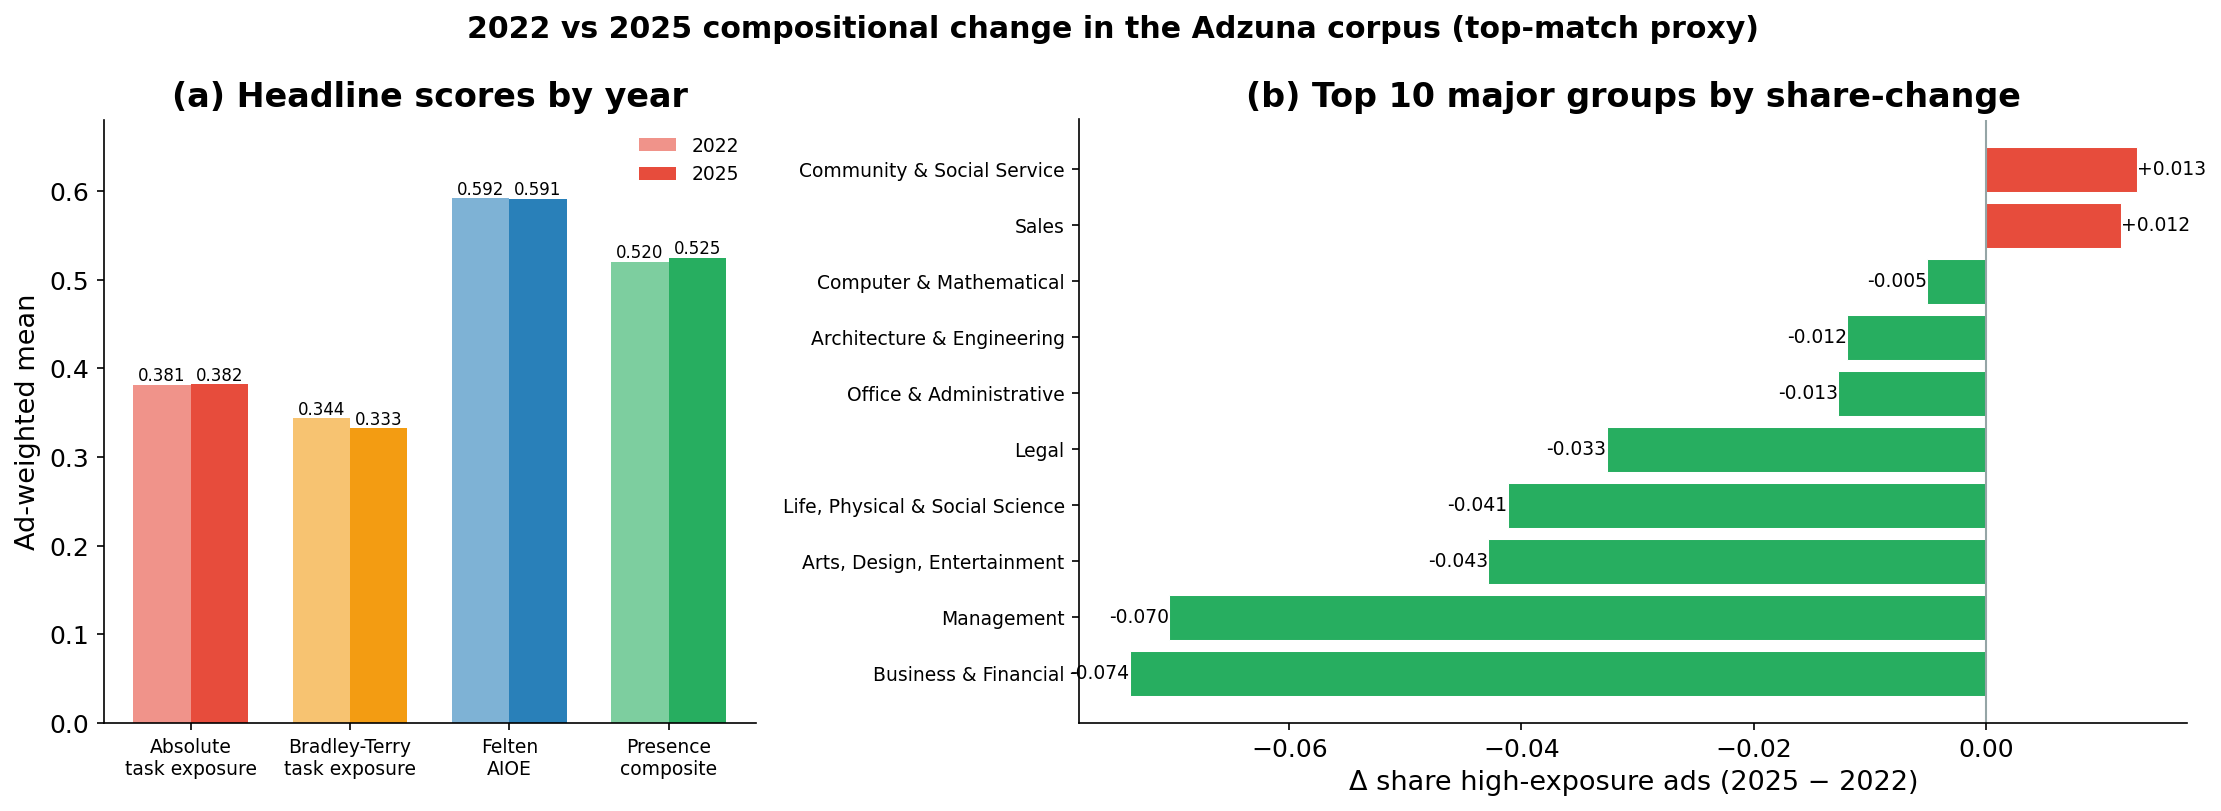

Saved /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/figures/temporal_change_summary.png

delta_mean_task_exposure_2022_2025    = +0.0006
delta_mean_task_exposure_bt_2022_2025 = -0.0113
top_3_rising  = ['Community & Social Service', 'Sales', 'Protective Service']
top_3_falling = ['Business & Financial', 'Management', 'Arts, Design, Entertainment']


In [ ]:
year_stats = con.execute(f"""
  SELECT year,
         COUNT(*)                          AS n_ads,
         AVG(task_exposure_mean)           AS mean_te_abs,
         MEDIAN(task_exposure_mean)        AS median_te_abs,
         QUANTILE_CONT(task_exposure_mean, 0.90) AS p90_te_abs,
         AVG(task_exposure_bt_mean)        AS mean_te_bt,
         MEDIAN(task_exposure_bt_mean)     AS median_te_bt,
         AVG(felten_score)                 AS mean_felten,
         AVG(presence_composite)           AS mean_presence,
         AVG(CASE WHEN task_exposure_mean >= {ad_q3_abs} THEN 1 ELSE 0 END) AS share_high_abs
  FROM ad_primary GROUP BY year ORDER BY year
""").fetchdf()
print("Ad-weighted statistics by year:")
print(year_stats.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# --- 7.1 Per major group: share of high-exposure ads in 2022 vs 2025 ----
major_year = con.execute(f"""
  SELECT primary_major_code AS major_code, year,
         COUNT(*) AS n_ads,
         AVG(CASE WHEN task_exposure_mean >= {ad_q3_abs} THEN 1 ELSE 0 END) AS share_high
  FROM ad_primary GROUP BY primary_major_code, year
""").fetchdf()
mg_pivot = major_year.pivot(index='major_code', columns='year', values='share_high')
mg_pivot.columns = [f'share_high_{int(c)}' for c in mg_pivot.columns]
mg_pivot['delta'] = mg_pivot['share_high_2025'] - mg_pivot['share_high_2022']
mg_pivot = mg_pivot.reset_index()
mg_pivot['major_group'] = mg_pivot['major_code'].map(ONET_MAJOR_NAMES)
mg_pivot = mg_pivot[['major_code', 'major_group',
                     'share_high_2022', 'share_high_2025', 'delta']]
mg_pivot.to_csv(TABLES_DIR / "temporal_change_by_major_group.csv", index=False)
print("\nMajor group: share of high-exposure ads, 2022 vs 2025:")
print(mg_pivot.to_string(index=False, float_format=lambda v: f'{v:+.4f}'))

# --- 7.2 Top occupational movers (ad volume change) -----------------------
occ_year = con.execute("""
  SELECT primary_onet AS onet_code, year, COUNT(*) AS n_ads
  FROM ad_primary GROUP BY primary_onet, year
""").fetchdf()
occ_pivot = occ_year.pivot(index='onet_code', columns='year', values='n_ads').fillna(0)
occ_pivot.columns = [f'n_ads_{int(c)}' for c in occ_pivot.columns]
# Per-year totals for normalised share comparison
total_2022 = int(year_stats.loc[year_stats.year == 2022, 'n_ads'].iloc[0])
total_2025 = int(year_stats.loc[year_stats.year == 2025, 'n_ads'].iloc[0])
occ_pivot['share_2022'] = occ_pivot['n_ads_2022'] / total_2022
occ_pivot['share_2025'] = occ_pivot['n_ads_2025'] / total_2025
occ_pivot['delta_share'] = occ_pivot['share_2025'] - occ_pivot['share_2022']
occ_pivot['delta_n_ads'] = occ_pivot['n_ads_2025'] - occ_pivot['n_ads_2022']
occ_pivot = occ_pivot.reset_index().merge(
    onet_df[['onet_code', 'title', 'major_group',
             'task_exposure_mean', 'task_exposure_bt_mean']], on='onet_code', how='left')
gainers = occ_pivot.nlargest(20, 'delta_share')
losers  = occ_pivot.nsmallest(20, 'delta_share')
movers = pd.concat([gainers.assign(direction='gainer'), losers.assign(direction='loser')], ignore_index=True)
movers = movers[['direction', 'onet_code', 'title', 'major_group',
                 'n_ads_2022', 'n_ads_2025', 'share_2022', 'share_2025',
                 'delta_share', 'delta_n_ads',
                 'task_exposure_mean', 'task_exposure_bt_mean']]
movers.to_csv(TABLES_DIR / "top_occupational_movers_2022_2025.csv", index=False)
print("\nTop 5 ad-share gainers (2022 -> 2025):")
print(gainers.head(5)[['title', 'major_group', 'n_ads_2022', 'n_ads_2025',
                       'delta_share', 'task_exposure_mean']]
      .to_string(index=False, float_format=lambda v: f'{v:+.4f}'))
print("\nTop 5 ad-share losers (2022 -> 2025):")
print(losers.head(5)[['title', 'major_group', 'n_ads_2022', 'n_ads_2025',
                      'delta_share', 'task_exposure_mean']]
      .to_string(index=False, float_format=lambda v: f'{v:+.4f}'))

# --- 7.3 Figure: small multiples (mean exposure by year + group changes) -
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                          gridspec_kw={'width_ratios': [1, 1.7]})

# Panel (a): mean exposure by year for the four headline scores
panel_cols = [('mean_te_abs', 'Absolute task exposure', ACCENT),
              ('mean_te_bt', 'Bradley-Terry task exposure', ORANGE),
              ('mean_felten', 'Felten AIOE', SECONDARY),
              ('mean_presence', 'Presence composite', GREEN)]
years_x = year_stats['year'].astype(int).tolist()
x = np.arange(len(panel_cols))
w = 0.36
for i, (col, label, color) in enumerate(panel_cols):
    v2022 = float(year_stats.loc[year_stats.year == 2022, col].iloc[0])
    v2025 = float(year_stats.loc[year_stats.year == 2025, col].iloc[0])
    axes[0].bar(i - w/2, v2022, w, color=color, alpha=0.6, label='2022' if i == 0 else None)
    axes[0].bar(i + w/2, v2025, w, color=color, alpha=1.0, label='2025' if i == 0 else None)
    axes[0].text(i - w/2, v2022, f'{v2022:.3f}', ha='center', va='bottom', fontsize=8)
    axes[0].text(i + w/2, v2025, f'{v2025:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([p[1].replace(' ', '\n', 1) for p in panel_cols], fontsize=9)
axes[0].set_ylabel('Ad-weighted mean')
axes[0].set_title('(a) Headline scores by year', fontweight='bold')
axes[0].legend(frameon=False, loc='upper right', fontsize=9)
axes[0].margins(y=0.15)

# Panel (b): top 10 major groups by change in high-exposure share
top10 = mg_pivot.reindex(mg_pivot['delta'].abs().sort_values(ascending=False).index).head(10)
top10 = top10.sort_values('delta')
colors_b = [ACCENT if d > 0 else GREEN for d in top10['delta']]
axes[1].barh(np.arange(len(top10)), top10['delta'], color=colors_b, edgecolor='white', linewidth=0.5)
axes[1].set_yticks(np.arange(len(top10)))
axes[1].set_yticklabels(top10['major_group'], fontsize=9)
axes[1].axvline(0, color=GREY_MED, linewidth=1)
axes[1].set_xlabel('Δ share high-exposure ads (2025 − 2022)')
axes[1].set_title('(b) Top 10 major groups by share-change', fontweight='bold')
for i, d in enumerate(top10['delta'].values):
    axes[1].text(d, i, f'{d:+.3f}', va='center',
                 ha='left' if d >= 0 else 'right', fontsize=9)
fig.suptitle('2022 vs 2025 compositional change in the Adzuna corpus (top-match proxy)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "temporal_change_summary.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR / 'temporal_change_summary.png'}")

# --- 7.4 JSON scalars ---------------------------------------------------
delta_mean_abs = (float(year_stats.loc[year_stats.year == 2025, 'mean_te_abs'].iloc[0])
                  - float(year_stats.loc[year_stats.year == 2022, 'mean_te_abs'].iloc[0]))
delta_mean_bt = (float(year_stats.loc[year_stats.year == 2025, 'mean_te_bt'].iloc[0])
                 - float(year_stats.loc[year_stats.year == 2022, 'mean_te_bt'].iloc[0]))
top3_rising = mg_pivot.nlargest(3, 'delta')['major_group'].tolist()
top3_falling = mg_pivot.nsmallest(3, 'delta')['major_group'].tolist()

topline_numbers['temporal'] = {
    'delta_mean_task_exposure_2022_2025': delta_mean_abs,
    'delta_mean_task_exposure_bt_2022_2025': delta_mean_bt,
    'top_3_major_groups_rising_high_exposure': top3_rising,
    'top_3_major_groups_falling_high_exposure': top3_falling,
    'mean_task_exposure_2022': float(year_stats.loc[year_stats.year == 2022, 'mean_te_abs'].iloc[0]),
    'mean_task_exposure_2025': float(year_stats.loc[year_stats.year == 2025, 'mean_te_abs'].iloc[0]),
    'mean_task_exposure_bt_2022': float(year_stats.loc[year_stats.year == 2022, 'mean_te_bt'].iloc[0]),
    'mean_task_exposure_bt_2025': float(year_stats.loc[year_stats.year == 2025, 'mean_te_bt'].iloc[0]),
}
print(f"\ndelta_mean_task_exposure_2022_2025    = {delta_mean_abs:+.4f}")
print(f"delta_mean_task_exposure_bt_2022_2025 = {delta_mean_bt:+.4f}")
print(f"top_3_rising  = {top3_rising}")
print(f"top_3_falling = {top3_falling}")

## Section 3c — Employment-weighted distribution (UK workforce)

**Deferred.** This section requires an ONS employment count at SOC 6-digit
(UK SOC2020) — typically ASHE Table 14 or BRES — and a SOC2020 → O\*NET-SOC
crosswalk. Neither artifact is in this repository. To activate, drop the
employment counts at `store/inputs/ashe_table14_employment.csv` and the
crosswalk at `store/inputs/soc2020_to_onetsoc.csv` and rebuild.

In [ ]:
topline_numbers['employment_weighted'] = 'deferred'
(TABLES_DIR / "employment_weighted_distribution.csv").write_text(
    "status,reason\n"
    "deferred,\"Requires ASHE Table 14 (or BRES) employment counts at SOC2020 6-digit "
    "and a SOC2020 to O*NET-SOC crosswalk. Provide both under store/inputs/ and rebuild.\"\n"
)
print("Section 3c stubbed as deferred.")

Section 3c stubbed as deferred.


## Section 9 — Export report pack

Assemble everything in one place for the report author:

1. `report_pack/topline_numbers.json` — every scalar accumulated above.
2. `report_pack/topline_tables.xlsx` — one sheet per CSV from `tables/`.
3. `report_pack/figures_manifest.csv` — filename, section, description, suggested report slot.
4. `report_pack/README.md` — one-page index of artifacts with the headline scalars surfaced.

In [ ]:
# 1. Topline numbers JSON
(REPORT_DIR / "topline_numbers.json").write_text(
    json.dumps(topline_numbers, indent=2, default=float) + "\n"
)
print(f"Wrote {REPORT_DIR / 'topline_numbers.json'}")

# 2. Combined Excel workbook
table_files = sorted(TABLES_DIR.glob("*.csv"))
xlsx_path = REPORT_DIR / "topline_tables.xlsx"
with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    for tf in table_files:
        # Excel sheet names: max 31 chars, no slashes
        sheet = tf.stem[:31].replace('/', '_')
        try:
            df = pd.read_csv(tf)
        except pd.errors.EmptyDataError:
            df = pd.DataFrame({'status': ['empty']})
        df.to_excel(writer, sheet_name=sheet, index=False)
print(f"Wrote {xlsx_path} with {len(table_files)} sheets")

# 3. Figures manifest
fig_descriptions = {
    'sampling_audit.png': ('Section 0', 'Per-year ad totals and LAD coverage in the 5M sample.', 'Coverage / methods note'),
    'ad_weighted_distribution.png': ('Section 3b', '2x2 histogram panel of ad-weighted scores (Adzuna corpus).', 'Distributional results'),
    'quadrant_counts_panel.png': ('Section 6', 'Quadrant counts at occupations / ads / LADs (canonical Q4xQ1 definition).', 'Vulnerability framework'),
    'top20_lads_tabular.png': ('Section 5', 'Top-20 LADs ranked bar chart, absolute and BT.', 'Geography section'),
    'temporal_change_summary.png': ('Section 7', '(a) Mean exposure by year; (b) major-group share-change.', 'Temporal change'),
    'correlation_matrix_extended.png': ('Section 8a', 'Cross-metric Spearman correlations (9 score columns).', 'Robustness / appendix'),
    'importance_weighting_scatter.png': ('Section 8b', 'Unweighted vs importance-weighted task exposure for both variants.', 'Robustness / appendix'),
}
manifest_rows = []
for fp in sorted(FIG_DIR.glob("*.png")):
    name = fp.name
    section, desc, slot = fig_descriptions.get(name, ('(legacy)', '(see notebook 01/02)', '(legacy)'))
    manifest_rows.append({'filename': name, 'source_section': section,
                           'description': desc, 'suggested_report_slot': slot})
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(REPORT_DIR / "figures_manifest.csv", index=False)
print(f"Wrote {REPORT_DIR / 'figures_manifest.csv'} ({len(manifest_df)} entries)")

# 4. README.md
def _fmt(v):
    if isinstance(v, float): return f'{v:.4f}'
    if isinstance(v, int):   return f'{v:,}'
    return str(v)

s = topline_numbers['sampling']
od = topline_numbers['occupation_distribution']
aw = topline_numbers['ad_weighted_distribution']
qd = topline_numbers['quadrants']
geo = topline_numbers['geography']
ct = topline_numbers['ad_weighted_contribution']
tp = topline_numbers['temporal']

readme = f"""# Topline report pack — production_5m

Generated by `nbs/analysis/03_topline_report_analysis.ipynb` at
{topline_numbers['metadata']['executed_at']}.

## Artifacts

| Path | Description |
|---|---|
| `data_dictionary.csv` / `.md` | Schema for every column of the three deliverable tables. |
| `topline_numbers.json` | Every scalar this notebook cites. Use this as the audit source for the written report. |
| `topline_tables.xlsx` | One sheet per CSV in `../tables/`. |
| `figures_manifest.csv` | Index of figures with section provenance and suggested report slot. |

Tables live in `../tables/`. Figures live in `../figures/`.

## Headline scalars

### Sample composition (5M Adzuna ads, random sample from the 2022 + 2025 corpus)
- Requested sample: {_fmt(s['n_ads_requested'])}
- Analysed (with at least one valid match): {_fmt(s['n_ads_with_match'])} ({s['match_rate']:.2%} of the requested sample).
- Dropped during matching: {_fmt(s['n_ads_dropped_upstream'])}.
- 2022 / 2025 split: {_fmt(s['n_ads_2022'])} / {_fmt(s['n_ads_2025'])}.
- LAD coverage on the analysed set: {s['lad_coverage_rate']:.2%} carry a `LAD22CD`.

### Occupation-level (861 O\\*NET occupations)
- Mean absolute task exposure: {od['mean_task_exposure_occ']:.4f} (median {od['median_task_exposure_occ']:.4f}, p90 {od['p90_task_exposure_occ']:.4f}).
- Mean Bradley-Terry task exposure: {od['mean_task_exposure_bt_occ']:.4f}.
- Mean Felten AIOE: {od['mean_felten_occ']:.4f}.
- Mean presence composite: {od['mean_presence_composite_occ']:.4f}.

### Ad-weighted (Adzuna corpus via 5M sample)
- Mean absolute task exposure: {aw['mean_task_exposure_ad']:.4f}.
- Mean Bradley-Terry task exposure: {aw['mean_task_exposure_bt_ad']:.4f}.
- Share of ads with absolute task exposure > 0.5: {aw['share_ads_task_exposure_gt_0_5']:.2%}.

### Quadrants (canonical Q4 exposure x Q1 presence, computed separately at each altitude)
- Vulnerable share: occupations {qd['share_occupations_vulnerable']:.2%} / ads {qd['share_ads_vulnerable']:.2%} / LADs {qd['share_lads_vulnerable']:.2%}.
- Augmented share: occupations {qd['share_occupations_augmented']:.2%} / ads {qd['share_ads_augmented']:.2%} / LADs {qd['share_lads_augmented']:.2%}.
- Augmented occupation count: {qd['n_augmented_occupations']}.

### Geography
- Top LAD by absolute task exposure: **{geo['top_lad_by_task_exposure']['LAD22NM']}** ({geo['top_lad_by_task_exposure']['LAD22CD']}, n_ads={_fmt(geo['top_lad_by_task_exposure']['n_ads'])}, score {geo['top_lad_by_task_exposure']['task_exposure_mean']:.4f}).
- London supplies {geo['london_share_of_all_high_exposure_ads']:.2%} of all high-exposure ads in the corpus (London has {geo['london_share_of_all_ads']:.2%} of all analysed ads -- so London is over-represented at the high end).
- Within London, {geo['within_london_high_exposure_rate']:.2%} of ads are high-exposure (vs the corpus-wide 25.00% by Q3 construction).

### Sectoral contribution (top-match proxy)
- Top 3 major groups by **within-group high-exposure rate**: {[r['major_group'] for r in ct['top_3_major_groups_by_high_exposure_rate']]} (rates: {[f"{r['rate']:.1%}" for r in ct['top_3_major_groups_by_high_exposure_rate']]}).
- Top 3 major groups by **share of all high-exposure ads**: {[r['major_group'] for r in ct['top_3_major_groups_by_share_of_all_high_exposure_ads']]} (shares: {[f"{r['share_of_all_high']:.1%}" for r in ct['top_3_major_groups_by_share_of_all_high_exposure_ads']]}).
- Top 5 major groups together supply {ct['share_of_all_high_exposure_ads_top_5_major_groups']:.2%} of all high-exposure ads.

### Temporal (2022 vs 2025)
- Δ mean absolute task exposure: {tp['delta_mean_task_exposure_2022_2025']:+.4f}.
- Δ mean BT task exposure: {tp['delta_mean_task_exposure_bt_2022_2025']:+.4f}.
- Top 3 rising in high-exposure share: {tp['top_3_major_groups_rising_high_exposure']}.
- Top 3 falling in high-exposure share: {tp['top_3_major_groups_falling_high_exposure']}.

### Deferred sections
- **Section 3c — employment-weighted UK workforce.** Needs ASHE Table 14 or BRES + SOC2020-to-O\\*NET-SOC crosswalk.
- **Section 5 ITL1 regional summary.** Needs ONS LAD-to-ITL1 lookup.
- **Section 8d — external benchmark comparison.** Needs Eloundou / Anthropic Economic Index occupation-level scores.
"""
(REPORT_DIR / "README.md").write_text(readme)
print(f"Wrote {REPORT_DIR / 'README.md'}")
print("\nReport pack complete.")

Wrote /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/report_pack/topline_numbers.json
Wrote /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/report_pack/topline_tables.xlsx with 21 sheets
Wrote /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/report_pack/figures_manifest.csv (44 entries)
Wrote /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/report_pack/README.md

Report pack complete.
